# Detección y seguimiento temporal de vegetación sobre una laguna usando Sentinel-2 y Sentinel-1

## Objetivo

Este proyecto tiene como objetivo detectar y cuantificar la vegetación presente sobre la superficie de una laguna a partir de imágenes satelitales, construyendo una serie temporal que permita analizar su comportamiento a lo largo del tiempo.

La metodología propuesta combina dos fuentes de información satelital:

- **Sentinel-2**, que se utiliza para delimitar la superficie de la laguna gracias a sus bandas ópticas, las cuales permiten diferenciar el agua de otros elementos del entorno.
- **Sentinel-1**, que se utiliza para monitorear en el tiempo la vegetación sobre el agua, aprovechando que el radar puede adquirir información incluso en presencia de nubes.

## Lógica general de trabajo

La estrategia metodológica sigue estos pasos:

1. Definir el área de estudio.
2. Construir una máscara fija del lago a partir de Sentinel-2.
3. Aplicar esa máscara a cada imagen de Sentinel-1.
4. Detectar dentro de la laguna la cobertura asociada a vegetación.
5. Calcular el área de vegetación en cada fecha.
6. Construir una serie temporal para analizar la evolución de la cobertura vegetal.

## Justificación

La combinación de Sentinel-2 y Sentinel-1 permite aprovechar las fortalezas de ambos sensores. Sentinel-2 ofrece mejor capacidad para identificar agua mediante índices espectrales, mientras que Sentinel-1 permite hacer seguimiento temporal continuo, incluso cuando las condiciones atmosféricas limitan el uso de imágenes ópticas.

In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate(auth_mode='notebook')
ee.Initialize()

## Definición del área de estudio

Se define manualmente el polígono que representa el área de interés (ROI, por sus siglas en inglés). Esta región corresponde a la laguna y su entorno inmediato. Trabajar con un ROI bien delimitado permite reducir ruido externo y enfocar el análisis únicamente en la zona relevante.

In [ ]:
# ROI de la laguna
roi = ee.Geometry.Polygon([
    [
        [-75.476052, 10.517524], # Longitud primero, luego Latitud
        [-75.476117, 10.518747],
        [-75.473158,10.519223 ],
        [-75.470516, 10.525108],
        [-75.469572, 10.524876],
        [-75.471686, 10.518916],
        [-75.468394, 10.517219],
        [-75.468952, 10.516459],
        [-75.476052, 10.517524]  # Cierre del polígono
    ]
])

### Preprocesamiento de Sentinel-2

Para construir una máscara confiable de la laguna, se utiliza la colección de superficie corregida de Sentinel-2. Antes de generar el compuesto, se aplica una función de enmascaramiento de nubes usando la banda `QA60`. Esto permite disminuir la contaminación por nubes y cirros, mejorando la delimitación del agua.

In [ ]:
def mask_s2_clouds(image):
    image = ee.Image(image) # Explicitly cast to Image
    qa = image.select('QA60')

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa.bitwiseAnd(cirrus_bit_mask).eq(0)
    )

    return image.updateMask(mask).divide(10000).copyProperties(image, ['system:time_start'])


###Construcción de la máscara fija de la laguna

En esta etapa se usa Sentinel-2 para identificar la superficie del agua. Para ello se genera un compuesto mediano del período de análisis y se calcula el índice **MNDWI** (Modified Normalized Difference Water Index), el cual resalta cuerpos de agua.

Posteriormente, se aplica un umbral al índice para separar agua de no agua. Finalmente, se realiza una limpieza morfológica básica para reducir píxeles aislados y mejorar la continuidad espacial de la máscara.

In [ ]:
def obtener_mascara_laguna(roi, fecha_inicio='2025-01-01', fecha_fin='2025-12-31'):
    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(roi)
          .filterDate(fecha_inicio, fecha_fin)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
          .map(mask_s2_clouds))

    composite = s2.median()

    # Índice MNDWI = (Green - SWIR1) / (Green + SWIR1)
    mndwi = composite.normalizedDifference(['B3', 'B11']).rename('MNDWI')

    # Umbral para identificar agua
    agua = mndwi.gt(0.05)

    # Limpieza morfológica básica
    agua_limpia = (agua
                   .focal_max(radius=1, units='pixels')
                   .focal_min(radius=1, units='pixels')
                   .rename('agua'))

    return agua_limpia

mascara_fija = obtener_mascara_laguna(roi)

##Cálculo del área total de la laguna

Una vez obtenida la máscara fija, se calcula automáticamente el área total de la laguna en metros cuadrados. Esto es importante porque permite luego expresar la vegetación detectada no solo como área absoluta, sino también como porcentaje de cobertura respecto al área total del cuerpo de agua.

In [ ]:
area_total_laguna = mascara_fija.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=10,
    maxPixels=1e9
).get('agua')

area_total_laguna = ee.Number(area_total_laguna).getInfo()
print(f"Área total estimada de la laguna: {area_total_laguna:.2f} m²")

Área total estimada de la laguna: 58897.36 m²


##Visualización de la máscara del lago

Se visualiza la máscara fija generada para verificar que la delimitación del lago sea razonable. Esta validación visual es importante porque permite comprobar si el agua fue bien separada del entorno urbano, los árboles cercanos y otras coberturas.

In [ ]:
Map = geemap.Map()
Map.centerObject(roi, 16)
Map.addLayer(mascara_fija.selfMask(), {'palette': ['blue']}, 'Máscara fija del lago')
Map.addLayer(roi, {'color': 'red'}, 'ROI', False)
Map

Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

##Selección de la colección Sentinel-1

Para el monitoreo temporal se utiliza Sentinel-1, un sensor radar que resulta especialmente útil porque no depende de la iluminación solar ni se ve tan afectado por la nubosidad.

Se filtra la colección para trabajar únicamente con imágenes homogéneas, seleccionando:

- modo de adquisición `IW`
- resolución de 10 metros
- polarizaciones `VV` y `VH`
- una misma dirección orbital (`DESCENDING`)

Esto ayuda a reducir variaciones no deseadas entre imágenes y mejora la consistencia de la serie temporal.

In [ ]:
fecha_inicio = '1950-01-01'
fecha_fin = '2025-12-31'

coleccion_radar = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate(fecha_inicio, fecha_fin)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('resolution_meters', 10))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
    .select(['VV', 'VH', 'angle']))

print('Número de imágenes radar:', coleccion_radar.size().getInfo())

Número de imágenes radar: 277


###Detección de vegetación sobre el agua

Cada imagen de Sentinel-1 se recorta al área de estudio y se enmascara usando la máscara fija del lago. De esta forma, el análisis se realiza únicamente sobre la superficie de agua.

Luego se aplica una regla basada en los valores de retrodispersión de las bandas `VV` y `VH`. Esta regla busca diferenciar áreas con posible presencia de vegetación flotante o vegetación sobre el agua frente a zonas de agua libre.

Finalmente, para cada fecha se calcula:

- el área estimada de vegetación en metros cuadrados
- el área total del lago
- el porcentaje de cobertura vegetal

Estos resultados se almacenan como una colección de atributos por fecha.

In [ ]:
def procesar_fecha(image):
    # Recortar la imagen al ROI y dejar solo la zona del lago
    img_laguna = image.clip(roi).updateMask(mascara_fija)

    vv = img_laguna.select('VV')
    vh = img_laguna.select('VH')

    # Regla simple para detectar vegetación sobre el agua
    vegetacion = vv.gt(-16).And(vh.gt(-22)).rename('veg')

    # Calcular área de vegetación
    area_veg = vegetacion.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=10,
        maxPixels=1e9
    ).get('veg')

    # Calcular área total del lago
    area_lago = mascara_fija.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=10,
        maxPixels=1e9
    ).get('agua')

    area_veg = ee.Number(area_veg)
    area_lago = ee.Number(area_lago)

    porcentaje = area_veg.divide(area_lago).multiply(100)

    return ee.Feature(None, {
        'fecha': image.date().format('YYYY-MM-dd'),
        'id_imagen': image.get('system:index'),
        'orbita': image.get('orbitProperties_pass'),
        'area_m2_vegetacion': area_veg,
        'area_m2_lago': area_lago,
        'porcentaje_cobertura': porcentaje
    })

###Construcción de la tabla de resultados

La función anterior se aplica a todas las imágenes de Sentinel-1 dentro del período de estudio. Después, los resultados se convierten en un `DataFrame` de Pandas para facilitar su análisis, organización y visualización.

In [ ]:
fc_resultados = coleccion_radar.map(procesar_fecha)
resultados = fc_resultados.getInfo()['features']

df = pd.DataFrame([f['properties'] for f in resultados])
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)

df

,area_m2_lago,area_m2_vegetacion,fecha,id_imagen,orbita,porcentaje_cobertura
0,58897.358411,8421.864441,2017-05-26,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...,DESCENDING,14.299223
1,58897.358411,6657.432907,2017-06-07,S1B_IW_GRDH_1SDV_20170607T104834_20170607T1049...,DESCENDING,11.303449
2,58897.358411,7090.690362,2017-06-19,S1B_IW_GRDH_1SDV_20170619T104834_20170619T1049...,DESCENDING,12.039063
3,58897.358411,7029.076869,2017-07-01,S1B_IW_GRDH_1SDV_20170701T104835_20170701T1049...,DESCENDING,11.934452
4,58897.358411,6571.486052,2017-07-13,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...,DESCENDING,11.157523
...,...,...,...,...,...,...
272,58897.358411,2983.758216,2025-12-04,S1A_IW_GRDH_1SDV_20251204T104942_20251204T1050...,DESCENDING,5.066031
273,58897.358411,3578.704223,2025-12-10,S1C_IW_GRDH_1SDV_20251210T104840_20251210T1049...,DESCENDING,6.076171
274,58897.358411,4053.954795,2025-12-16,S1A_IW_GRDH_1SDV_20251216T104941_20251216T1050...,DESCENDING,6.883084
275,58897.358411,3072.057966,2025-12-22,S1C_IW_GRDH_1SDV_20251222T104839_20251222T1049...,DESCENDING,5.215952


###Preparación de la serie temporal

Se organiza una tabla final con las variables más importantes del análisis temporal:

- fecha de adquisición
- área de vegetación detectada
- porcentaje de cobertura
- identificador de la imagen
- tipo de órbita

Esta tabla constituye la base de la serie temporal del proyecto.

In [ ]:
df_ts = df[['fecha', 'area_m2_vegetacion', 'porcentaje_cobertura', 'id_imagen', 'orbita']].copy()
df_ts.head()

,fecha,area_m2_vegetacion,porcentaje_cobertura,id_imagen,orbita
0,2017-05-26,8421.864441,14.299223,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...,DESCENDING
1,2017-06-07,6657.432907,11.303449,S1B_IW_GRDH_1SDV_20170607T104834_20170607T1049...,DESCENDING
2,2017-06-19,7090.690362,12.039063,S1B_IW_GRDH_1SDV_20170619T104834_20170619T1049...,DESCENDING
3,2017-07-01,7029.076869,11.934452,S1B_IW_GRDH_1SDV_20170701T104835_20170701T1049...,DESCENDING
4,2017-07-13,6571.486052,11.157523,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...,DESCENDING


## Visualización de un caso de ejemplo

Para complementar la serie temporal, se selecciona una imagen de Sentinel-1 y se visualiza la vegetación detectada sobre la superficie de la laguna. Esta visualización permite comparar espacialmente la zona de agua con la cobertura identificada y validar de forma cualitativa el resultado del algoritmo.

In [ ]:
imagen_radar = ee.Image(coleccion_radar.first())
imagen_solo_laguna = imagen_radar.clip(roi).updateMask(mascara_fija)

capa_vegetacion = (
    imagen_solo_laguna.select('VV').gt(-16)
    .And(imagen_solo_laguna.select('VH').gt(-22))
)

Map = geemap.Map()
Map.centerObject(roi, 16)

Map.addLayer(mascara_fija.selfMask(), {'palette': ['#0000AA']}, 'Lago')
Map.addLayer(imagen_solo_laguna.select('VV'),
             {'min': -25, 'max': 0},
             'Sentinel-1 VV', False)
Map.addLayer(capa_vegetacion.selfMask(),
             {'palette': ['#00FF00']},
             'Vegetación detectada')
Map.addLayer(roi, {'color': 'red'}, 'ROI', False)

Map

Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

#### Seleccionar automáticamente las 5 fechas

In [ ]:
# ==========================================================
# 3 en el periodo de picos (septiembre-octubre)
# 2 fuera de ese periodo
# ==========================================================

# Asegurarnos de que la fecha esté en formato datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Si hay varias imágenes el mismo día, nos quedamos con una sola por fecha
# tomando la de mayor vegetación para esa fecha
df_unico = (df.sort_values(['fecha', 'area_m2_vegetacion'], ascending=[True, False])
              .drop_duplicates(subset='fecha')
              .copy())

# Periodo donde sospechas que está el pico
df_picos = df_unico[df_unico['fecha'].dt.month.isin([9, 10])].copy()

# Fuera del periodo de picos
df_fuera = df_unico[~df_unico['fecha'].dt.month.isin([9, 10])].copy()

# Tomar las 3 fechas con mayor vegetación en septiembre-octubre
top_3_picos = df_picos.nlargest(3, 'area_m2_vegetacion').copy()

# Tomar 2 fechas fuera de septiembre-octubre:
# una con vegetación baja y otra con vegetación relativamente alta
fuera_baja = df_fuera.nsmallest(1, 'area_m2_vegetacion').copy()
fuera_alta = df_fuera.nlargest(1, 'area_m2_vegetacion').copy()

# Unir selección
fechas_ejemplo = pd.concat([top_3_picos, fuera_baja, fuera_alta]).drop_duplicates(subset='fecha')

# Ordenar cronológicamente
fechas_ejemplo = fechas_ejemplo.sort_values('fecha').reset_index(drop=True)

print("Fechas seleccionadas:")
display(fechas_ejemplo[['fecha', 'area_m2_vegetacion']])

Fechas seleccionadas:


,fecha,area_m2_vegetacion
0,2019-04-10,562.373642
1,2020-07-21,11710.551849
2,2020-09-07,9172.609897
3,2020-09-19,7668.369522
4,2025-10-11,12874.152405


Ver cuáles fueron realmente las fechas escogidas

In [ ]:
# Mostrar las fechas en texto
for i, row in fechas_ejemplo.iterrows():
    print(f"Imagen {i+1}: {row['fecha'].strftime('%Y-%m-%d')} | Área vegetación: {row['area_m2_vegetacion']:.2f} m²")

Imagen 1: 2019-04-10 | Área vegetación: 562.37 m²
Imagen 2: 2020-07-21 | Área vegetación: 11710.55 m²
Imagen 3: 2020-09-07 | Área vegetación: 9172.61 m²
Imagen 4: 2020-09-19 | Área vegetación: 7668.37 m²
Imagen 5: 2025-10-11 | Área vegetación: 12874.15 m²



Función para buscar una imagen de Sentinel-1 cercana a una fecha

Esto sirve porque a veces la fecha del DataFrame y la fecha exacta de la imagen deben buscarse en un rango pequeño.

In [ ]:
# ==========================================================
# FUNCIÓN PARA ENCONTRAR UNA IMAGEN CERCA DE UNA FECHA
# ==========================================================
def obtener_imagen_por_fecha(fecha_str, ventana_dias=2):
    fecha = ee.Date(fecha_str)

    imagen = (coleccion_radar
              .filterDate(fecha.advance(-ventana_dias, 'day'),
                          fecha.advance(ventana_dias + 1, 'day'))
              .sort('system:time_start')
              .first())

    return ee.Image(imagen)



In [ ]:
def obtener_imagen_por_id(id_imagen):
    imagen = coleccion_radar.filter(ee.Filter.eq('system:index', id_imagen)).first()
    return ee.Image(imagen)

In [ ]:
def mostrar_imagen_por_id(id_imagen, fecha_str, umbral_vv=-16, umbral_vh=-22):
    imagen = obtener_imagen_por_id(id_imagen)
    imagen_solo_laguna = imagen.clip(roi).updateMask(mascara_fija)

    vv = imagen_solo_laguna.select('VV')
    vh = imagen_solo_laguna.select('VH')

    capa_vegetacion = vv.gt(umbral_vv).And(vh.gt(umbral_vh))

    Map = geemap.Map()
    Map.centerObject(roi, 16)

    Map.addLayer(
        imagen_solo_laguna.select('VV'),
        {'min': -25, 'max': 0},
        f'Sentinel-1 VV {fecha_str}'
    )

    Map.addLayer(
        mascara_fija.selfMask(),
        {'palette': ['#0000AA']},
        'Máscara de lago'
    )

    Map.addLayer(
        capa_vegetacion.selfMask(),
        {'palette': ['#00FF00']},
        f'Vegetación detectada ({fecha_str})'
    )

    Map.addLayer(roi, {'color': 'red'}, 'ROI', False)

    return Map

In [ ]:
for i, row in fechas_ejemplo.iterrows():
    fecha_str = row['fecha'].strftime('%Y-%m-%d')
    area_veg = row['area_m2_vegetacion']
    id_imagen = row['id_imagen']

    print(f"\nImagen {i+1} - Fecha: {fecha_str} | Área de vegetación: {area_veg:.2f} m²")
    display(mostrar_imagen_por_id(id_imagen, fecha_str))


Imagen 1 - Fecha: 2019-04-10 | Área de vegetación: 562.37 m²


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Imagen 2 - Fecha: 2020-07-21 | Área de vegetación: 11710.55 m²


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Imagen 3 - Fecha: 2020-09-07 | Área de vegetación: 9172.61 m²


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Imagen 4 - Fecha: 2020-09-19 | Área de vegetación: 7668.37 m²


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Imagen 5 - Fecha: 2025-10-11 | Área de vegetación: 12874.15 m²


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

#### Función para visualizar una imagen con la vegetación detectada

Aquí uso tu misma lógica de detección con VV > -15, para que seas coherente con tu trabajo actual.

In [ ]:
def mostrar_imagen_vegetacion(fecha_str, umbral_vv=-16, umbral_vh=-22):
    imagen = obtener_imagen_por_fecha(fecha_str)
    imagen_solo_laguna = imagen.clip(roi).updateMask(mascara_fija)

    vv = imagen_solo_laguna.select('VV')
    vh = imagen_solo_laguna.select('VH')

    # Mismo criterio usado en la serie temporal
    capa_vegetacion = vv.gt(umbral_vv).And(vh.gt(umbral_vh))

    Map = geemap.Map()
    Map.centerObject(roi, 16)

    Map.addLayer(
        imagen_solo_laguna.select('VV'),
        {'min': -25, 'max': 0},
        f'Sentinel-1 VV {fecha_str}'
    )

    Map.addLayer(
        mascara_fija.selfMask(),
        {'palette': ['#0000AA']},
        'Máscara de lago'
    )

    Map.addLayer(
        capa_vegetacion.selfMask(),
        {'palette': ['#00FF00']},
        f'Vegetación detectada ({fecha_str})'
    )

    Map.addLayer(roi, {'color': 'red'}, 'ROI', False)

    return Map

In [ ]:
# ==========================================================
# MOSTRAR LAS 5 IMÁGENES SELECCIONADAS
# ==========================================================
for i, row in fechas_ejemplo.iterrows():
    fecha_str = row['fecha'].strftime('%Y-%m-%d')
    area_veg = row['area_m2_vegetacion']

    print(f"\nImagen {i+1} - Fecha: {fecha_str} | Área de vegetación: {area_veg:.2f} m²")
    display(mostrar_imagen_vegetacion(fecha_str, umbral_vv=-15))


Imagen 1 - Fecha: 2019-04-10 | Área de vegetación: 562.37 m²


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Imagen 2 - Fecha: 2020-07-21 | Área de vegetación: 11710.55 m²


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Imagen 3 - Fecha: 2020-09-07 | Área de vegetación: 9172.61 m²


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Imagen 4 - Fecha: 2020-09-19 | Área de vegetación: 7668.37 m²


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Imagen 5 - Fecha: 2025-10-11 | Área de vegetación: 12874.15 m²


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

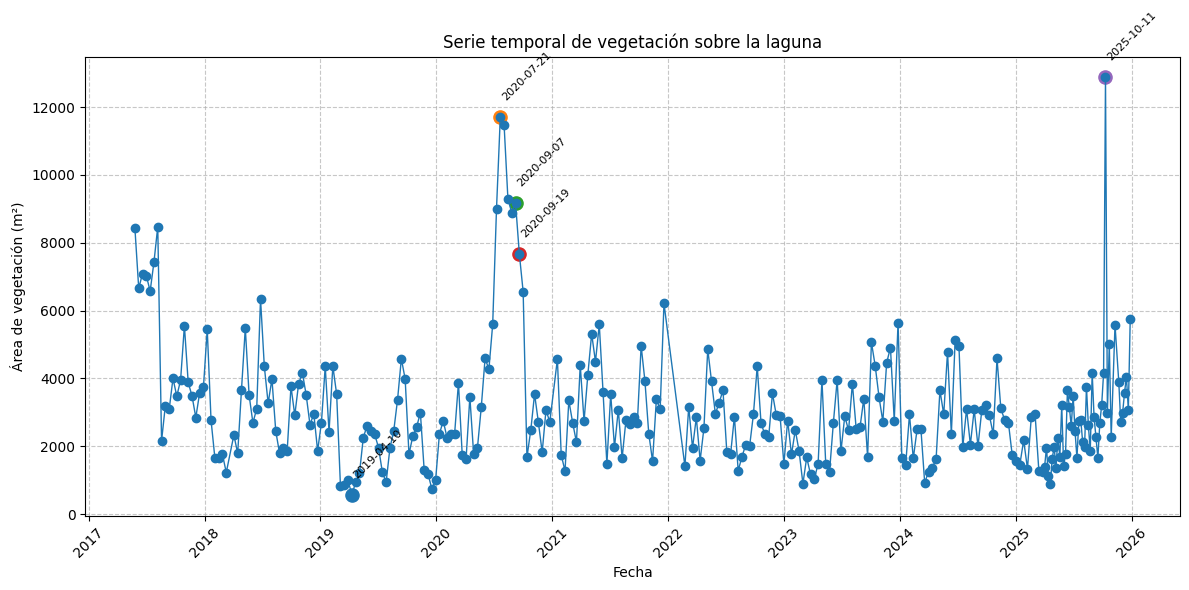

In [ ]:
# ==========================================================
# GRAFICAR SERIE TEMPORAL Y MARCAR LAS 5 FECHAS SELECCIONADAS
# ==========================================================

plt.figure(figsize=(12, 6))
plt.plot(df_ts['fecha'], df_ts['area_m2_vegetacion'], linewidth=1, marker='o')
plt.title('Serie temporal de vegetación sobre la laguna')
plt.xlabel('Fecha')
plt.ylabel('Área de vegetación (m²)')
plt.grid(True, linestyle='--', alpha=0.7)

for _, row in fechas_ejemplo.iterrows():
    plt.scatter(row['fecha'], row['area_m2_vegetacion'], s=90)
    plt.text(
        row['fecha'],
        row['area_m2_vegetacion'] + 500,
        row['fecha'].strftime('%Y-%m-%d'),
        fontsize=8,
        rotation=45
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# PROBAR DIFERENTES UMBRALES EN UNA FECHA
# ==========================================================
def comparar_umbrales(fecha_str, umbrales=[-16, -15, -14, -13]):
    imagen = obtener_imagen_por_fecha(fecha_str)
    imagen_solo_laguna = imagen.clip(roi).updateMask(mascara_fija)

    for umbral in umbrales:
        capa_vegetacion = imagen_solo_laguna.select('VV').gt(umbral)

        print(f"\nFecha: {fecha_str} | Umbral VV > {umbral}")
        Map = geemap.Map()
        Map.centerObject(roi, 16)

        Map.addLayer(
            imagen_solo_laguna.select('VV'),
            {'min': -25, 'max': 0},
            f'VV {fecha_str}'
        )

        Map.addLayer(
            mascara_fija.selfMask(),
            {'palette': ['#0000AA']},
            'Máscara de lago'
        )

        Map.addLayer(
            capa_vegetacion.selfMask(),
            {'palette': ['#00FF00']},
            f'Vegetación detectada VV>{umbral}'
        )

        Map.addLayer(roi, {'color': 'red'}, 'ROI', False)
        display(Map)

In [ ]:
# Probar distintos umbrales con la primera fecha pico seleccionada
fecha_prueba = top_3_picos.iloc[0]['fecha'].strftime('%Y-%m-%d')
comparar_umbrales(fecha_prueba, umbrales=[-16, -15, -14, -13])


Fecha: 2025-10-11 | Umbral VV > -16


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Fecha: 2025-10-11 | Umbral VV > -15


Map(center=[10.519386983714051, -75.47203874749312], controls=(WidgetControl(options=['position', 'transparent…


Fecha: 2025-10-11 | Umbral VV > -14


Map(center=[10.519386983714051, -75.47203874749312], controls=(WidgetControl(options=['position', 'transparent…


Fecha: 2025-10-11 | Umbral VV > -13


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

## Visualización del porcentaje de cobertura vegetal

Además del área absoluta, también se representa el porcentaje de cobertura respecto al área total de la laguna. Esta métrica es útil porque permite interpretar la magnitud de la vegetación en términos relativos, facilitando comparaciones entre fechas.

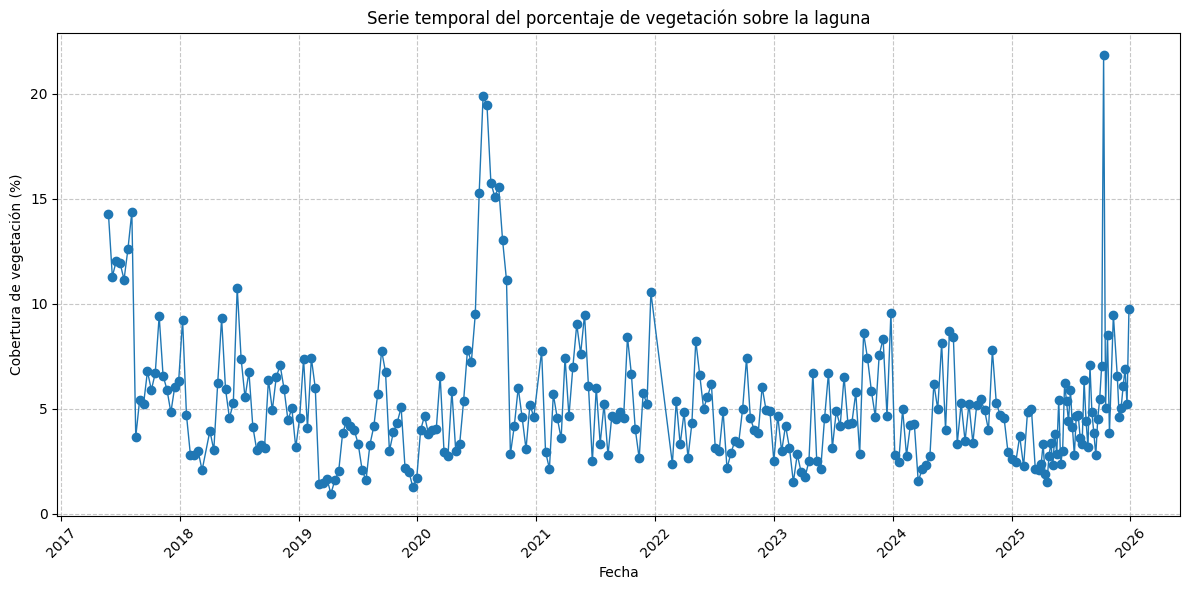

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_ts['fecha'], df_ts['porcentaje_cobertura'], marker='o', linewidth=1)
plt.title('Serie temporal del porcentaje de vegetación sobre la laguna')
plt.xlabel('Fecha')
plt.ylabel('Cobertura de vegetación (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Visualización de la serie temporal del área de vegetación

Se genera una gráfica de líneas para observar cómo cambia el área de vegetación sobre la laguna a lo largo del tiempo. Esta representación permite identificar aumentos, disminuciones, patrones estacionales o fechas con comportamientos atípicos.

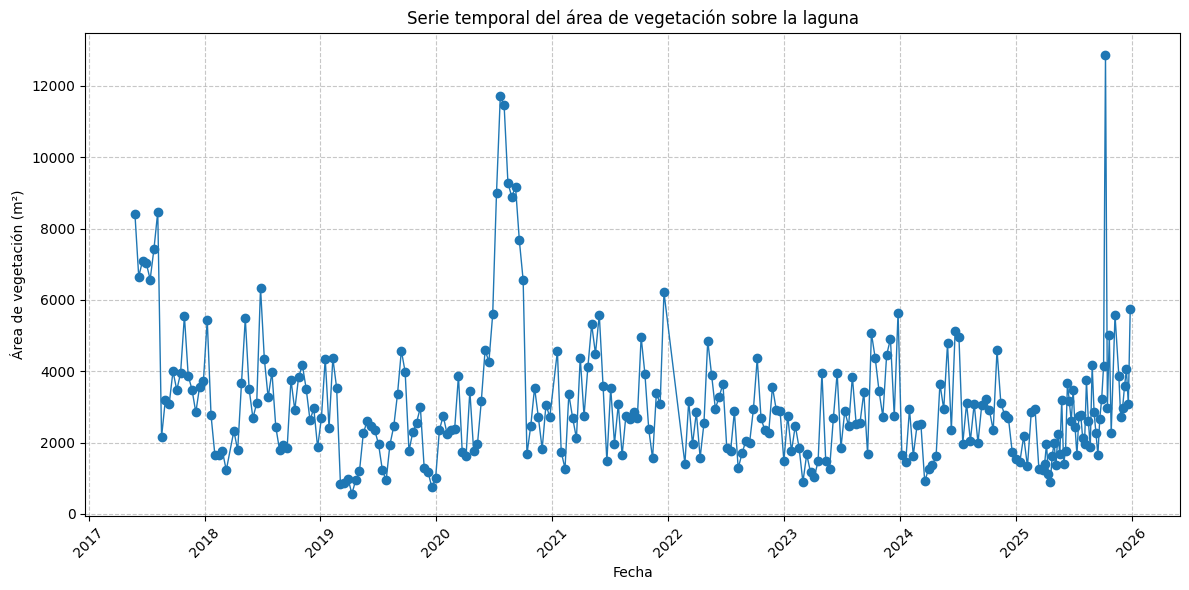

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_ts['fecha'], df_ts['area_m2_vegetacion'], marker='o', linewidth=1)
plt.title('Serie temporal del área de vegetación sobre la laguna')
plt.xlabel('Fecha')
plt.ylabel('Área de vegetación (m²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Problema de la Serie de Tiempo

Vemos que al intentar sacar una serie temporal desde 1950 hasta 2025 solo sale los datos desde el **2017 en adelante** porque el **Sentinel 1 es una mision moderna** fue lanzado en 2014 y en algunas zonas del meridiano empezo a estabilizarse para el 2017 o 2018 por lo que tenemso 2 posibles approach a seguir:

1. Ver la serie de tiempo y analizarla desde el 2017 en adelante

- Ver componentes de la serie

- Realizar algunas pruebas

2. Intentar usar otras opciones para sacar esos datos de antes del 2017

- Landsat 5 tiene datos desde **1984 hasta 2012**

- Landsat 8 **desde 2013 hasta la actualidad**

- **Sentinel-2**: Con datos desde **2015 hasta la actualidad**. Se intentó usar para rellenar el hueco entre 2015 y 2017, pero **fracasó debido a la extrema escasez de imágenes utilizables** (solo 1 imagen válida incluso relajando filtros de nubes), lo que lo hizo inviable para la serie temporal.

Limitaciones: Al ser sensores opticos como el Sentinel-2 se ven afectados por las nubes

## 1er Approach

Para analizar el comportamiento de la vegetación en la laguna de forma robusta, realizamos una descomposición de serie temporal. Dado que las capturas satelitales pueden ser irregulares, primero remuestreamos los datos a una frecuencia mensual (MS) utilizando interpolación lineal para completar posibles vacíos. Posteriormente, aplicamos un modelo aditivo para separar la serie en su tendencia a largo plazo, su componente estacional anual y el ruido residual, permitiéndonos identificar patrones cíclicos independientes de eventos aleatorios.

---
Para llevar a cabo esto realizaremos la metodologia:


```
Box-jenkins
```



### Descompocision de la Serie

Periodo aproximado para la estacionalidad: 30


<Figure size 1200x800 with 0 Axes>

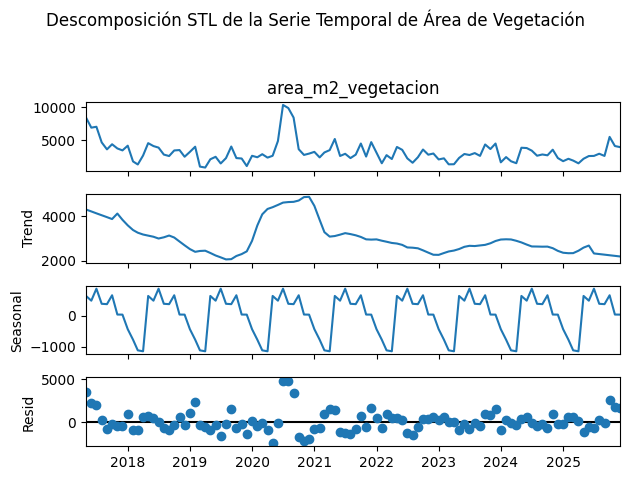

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_ts_indexed = df_ts.set_index('fecha')
diff_days = df_ts['fecha'].diff().dt.days.mean()
median_days_between_observations = df_ts['fecha'].diff().dt.days.median()
if median_days_between_observations is not None and median_days_between_observations > 0:
    approx_period = round(365 / median_days_between_observations)
else:
    approx_period = 30 # Valor por defecto si no se puede calcular

print(f"Periodo aproximado para la estacionalidad: {approx_period}")
if approx_period < 2:
    approx_period = 30
df_ts_resampled = df_ts_indexed['area_m2_vegetacion'].resample('MS').mean().interpolate()

result = seasonal_decompose(df_ts_resampled, model='additive', period=12, extrapolate_trend='freq')

plt.figure(figsize=(12, 8))
result.plot()
plt.suptitle('Descomposición STL de la Serie Temporal de Área de Vegetación', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Comparacion

Veamos que tanto cambio la Serie de tiempo al aplicarle esa interpolacion

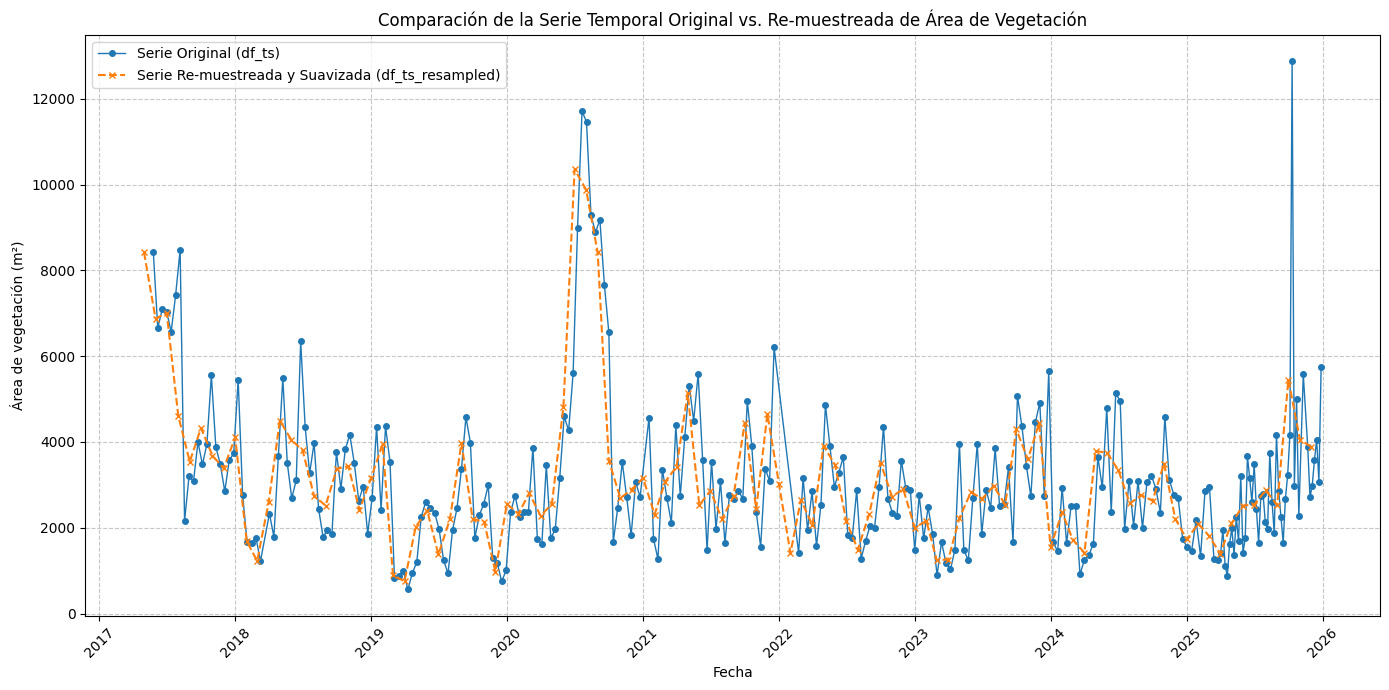

In [ ]:
plt.figure(figsize=(14, 7))

# Plot de la serie temporal original
plt.plot(df_ts['fecha'], df_ts['area_m2_vegetacion'], marker='o', linestyle='-', linewidth=1, markersize=4, label='Serie Original (df_ts)')

# Plot de la serie temporal re-muestreada y suavizada (df_ts_resampled)
plt.plot(df_ts_resampled.index, df_ts_resampled, marker='x', linestyle='--', linewidth=1.5, markersize=4, label='Serie Re-muestreada y Suavizada (df_ts_resampled)')

plt.title('Comparación de la Serie Temporal Original vs. Re-muestreada de Área de Vegetación')
plt.xlabel('Fecha')
plt.ylabel('Área de vegetación (m²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Estacionariedad

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

def check_stationarity(series):
    # 1. Prueba ADF (Hipótesis Nula: La serie NO es estacionaria / tiene raíz unitaria)
    adf_result = adfuller(series)
    print(f'--- Prueba ADF ---')
    print(f'Estadístico ADF: {adf_result[0]:.4f}')
    print(f'p-valor: {adf_result[1]:.4f}')

    # 2. Prueba KPSS (Hipótesis Nula: La serie ES estacionaria)
    kpss_result = kpss(series, regression='c', nlags="auto")
    print(f'\n--- Prueba KPSS ---')
    print(f'Estadístico KPSS: {kpss_result[0]:.4f}')
    print(f'p-valor: {kpss_result[1]:.4f}')

check_stationarity(df_ts_resampled)

--- Prueba ADF ---
Estadístico ADF: -5.2688
p-valor: 0.0000

--- Prueba KPSS ---
Estadístico KPSS: 0.2672
p-valor: 0.1000


/tmp/ipykernel_2463/3392258735.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags="auto")


En conclusion:

1. La prueba **ADF**: nos dió un p_value menor a 0.05 por lo que se **Rechaza la H0 de que NO es Estacionaria**, es decir, Es estacionaria

2. La prueba **KPSS**: nos dió un p_value mayor a 0.05 por lo que **NO se rechaza la H0 de que la serie Es Estacionaria**, es decir, Es estacionaria

Por lo tanto, no se requiere aplicar diferenciación ($d=0$) para modelos de la familia ARIMA, y los supuestos de media y varianza constantes para modelos de regresión se cumplen satisfactoriamente. Esto probablemente nos da pie para escojer algun modelo **ARIMA(p,0,q)**, sin embargo, lo ideal antes de eso seria ver la autocorrelacion haciendo los graficos **ACF y  PACF** para ver los ordenes que temdrá el modelo (p,q) y la estacionalidad

### Autocorrelacion

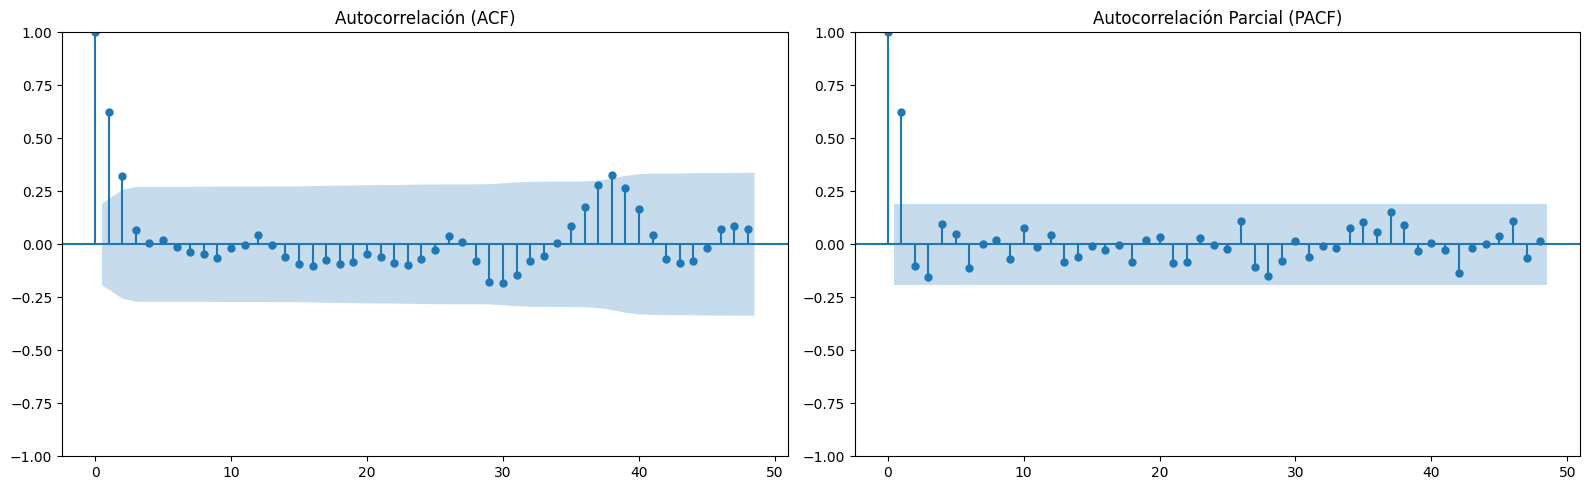

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df_ts_resampled, lags=48, ax=axes[0], title='Autocorrelación (ACF)')
plot_pacf(df_ts_resampled, lags=48, ax=axes[1], title='Autocorrelación Parcial (PACF)', method='ywm')

plt.tight_layout()
plt.show()

En conclusion:

1. **ACF**: Los rezagos 1 y 2 son **significativos** lo que nos da a entender que la vegetacion que hay este mes depende fuertemente de los 2 meses anteriores, ademas vemos que entre el lag 10 y 30 o 35 estan todos dentro de la banda, es decir, la serie pierde memoria de lo que pasó hace 1 año y medio mas o menos

2. **PACF**: Vemos un corte abruptisimo despues del rezago 1, esto en la literatura es un **AR(1)** de manual y tiene sentido porque lo que nos dice es que depende fuertemente del mes anterior

El análisis de las funciones de autocorrelación revela una estructura Autorregresiva de orden 1 (AR1) predominante. En el PACF, se observa un único pico significativo en el primer rezago, lo que indica que el valor presente de la vegetación es altamente dependiente de su estado inmediato anterior. Por otro lado, el ACF muestra un comportamiento oscilatorio con un resurgimiento de la correlación cerca del tercer año (lags 36-40), lo que podría estar vinculado a ciclos climáticos plurianuales que afectan el nivel hídrico de la laguna en Cartagena

### Modelo

#### 1. Manual

Por lo que vimos en el ACF y PACF parece que lo ideal seria un SARIMA que tenga en orden no estacional un (1,0,0) y en el estacional uno de 12 meses

                                     SARIMAX Results                                      
Dep. Variable:                 area_m2_vegetacion   No. Observations:                  104
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -782.930
Date:                            Tue, 07 Apr 2026   AIC                           1571.861
Time:                                    15:39:20   BIC                           1579.393
Sample:                                05-01-2017   HQIC                          1574.900
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9003      0.037     24.636      0.000       0.829       0.972
ar.S.L12       0.1236      0.108   

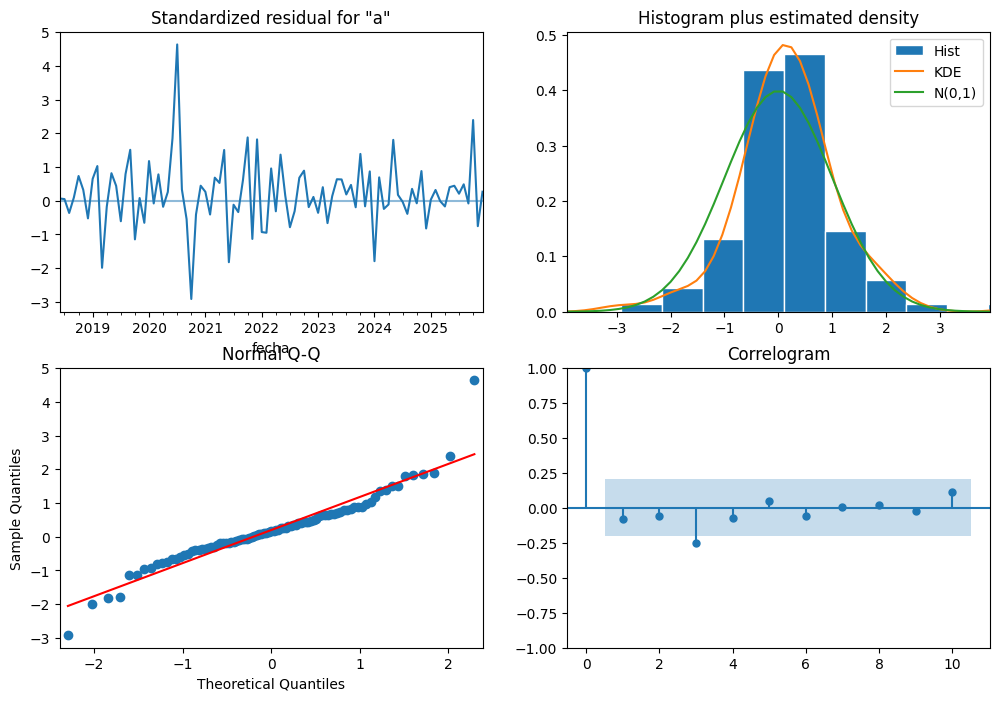

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df_ts_resampled,
                order=(1, 0, 0),
                seasonal_order=(1, 0, 0, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit()

print(results.summary())

results.plot_diagnostics(figsize=(12, 8))
plt.show()

El modelo SARIMA(1,0,0)(1,0,0)[12] demuestra un ajuste robusto con un coeficiente autorregresivo altamente significativo ($\phi=0.90, p<0.001$), validando la fuerte dependencia inercial de la vegetación. El análisis de residuos a través del correlograma muestra que el modelo ha extraído exitosamente la estructura de autocorrelación de la serie. Aunque existen desviaciones en la normalidad de los residuos debido a eventos climáticos extremos en 2020 y 2025, el AIC de 1571.8 establece una base sólida para la generación de pronósticos

---


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.3 MB/s eta 0:00:00


#### 2. AUTO ARIMA

In [ ]:
import pmdarima as pm

auto_model = pm.auto_arima(df_ts_resampled,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           m=12,
                           start_P=0, seasonal=True,
                           d=0, D=0,         # Ya sabemos que es estacionaria
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=1844.183, Time=0.31 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1842.473, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1788.800, Time=0.16 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1806.504, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1998.045, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1786.780, Time=0.08 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1788.195, Time=0.10 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=1789.881, Time=0.42 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=1788.090, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=1788.047, Time=0.56 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=1803.683, Time=0.23 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=1791.143, Time=0.33 sec
 ARIMA(1,0,0)(0,0,0)[12]             : AIC=1799.962, Time=0.08 sec

Best model:  ARIMA(1,0,0)(0,0,0)[12] intercept
Total fit time: 2.514 seconds
        

Al aplicar el algoritmo Auto-ARIMA, se confirmó la naturaleza autorregresiva de la serie. El modelo óptimo identificado fue un ARIMA(1,0,0), el cual prioriza la simplicidad y la reversión a la media. A diferencia del modelo manual, el algoritmo sugiere que la influencia del mes anterior ($\phi=0.65$) y un intercepto constante son suficientes para describir la dinámica de la vegetación, minimizando el riesgo de sobreajuste al omitir componentes estacionales explícitos que podrían ser capturados por la inercia del propio proceso autorregresivo.

### Pronosticos

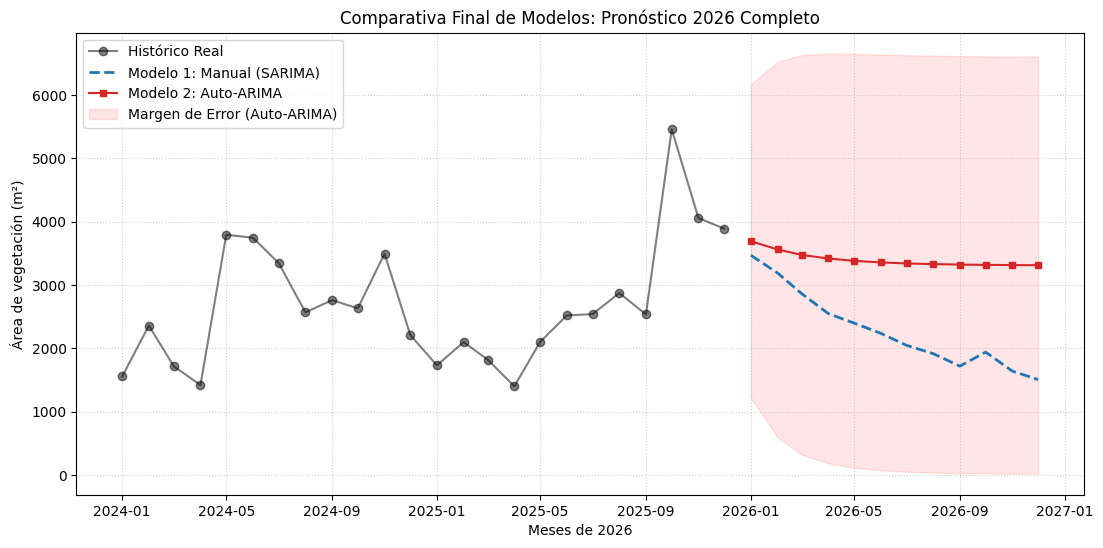

In [ ]:
n_steps = 12

forecast_1_obj = results.get_forecast(steps=n_steps)
f1_mean = forecast_1_obj.predicted_mean
f1_ci = forecast_1_obj.conf_int()

f2_mean, f2_ci = auto_model.predict(n_periods=n_steps, return_conf_int=True)

last_date = df_ts_resampled.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1),
                               periods=n_steps,
                               freq='MS')

plt.figure(figsize=(13, 6))

plt.plot(df_ts_resampled.index[-24:], df_ts_resampled[-24:],
         label='Histórico Real', color='black', marker='o', alpha=0.5)

plt.plot(forecast_index, f1_mean, label='Modelo 1: Manual (SARIMA)',
         color='#1f77b4', linestyle='--', lw=2)

plt.plot(forecast_index, f2_mean, label='Modelo 2: Auto-ARIMA',
         color='#d62728', marker='s', markersize=4)

plt.fill_between(forecast_index, f2_ci[:, 0], f2_ci[:, 1],
                 color='red', alpha=0.1, label='Margen de Error (Auto-ARIMA)')

plt.title('Comparativa Final de Modelos: Pronóstico 2026 Completo')
plt.xlabel('Meses de 2026')
plt.ylabel('Área de vegetación (m²)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Comparacion

In [ ]:
fecha_inicio_2026 = '2026-01-01'
fecha_fin_2026 = '2026-03-31'

coleccion_2026 = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate(fecha_inicio_2026, fecha_fin_2026)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('resolution_meters', 10))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
    .select(['VV', 'VH', 'angle']))

fc_2026 = coleccion_2026.map(procesar_fecha)
resultados_2026 = fc_2026.getInfo()['features']

df_2026_real = pd.DataFrame([f['properties'] for f in resultados_2026])
df_2026_real['fecha'] = pd.to_datetime(df_2026_real['fecha'])

df_2026_mensual = df_2026_real.set_index('fecha')['area_m2_vegetacion'].resample('MS').mean()

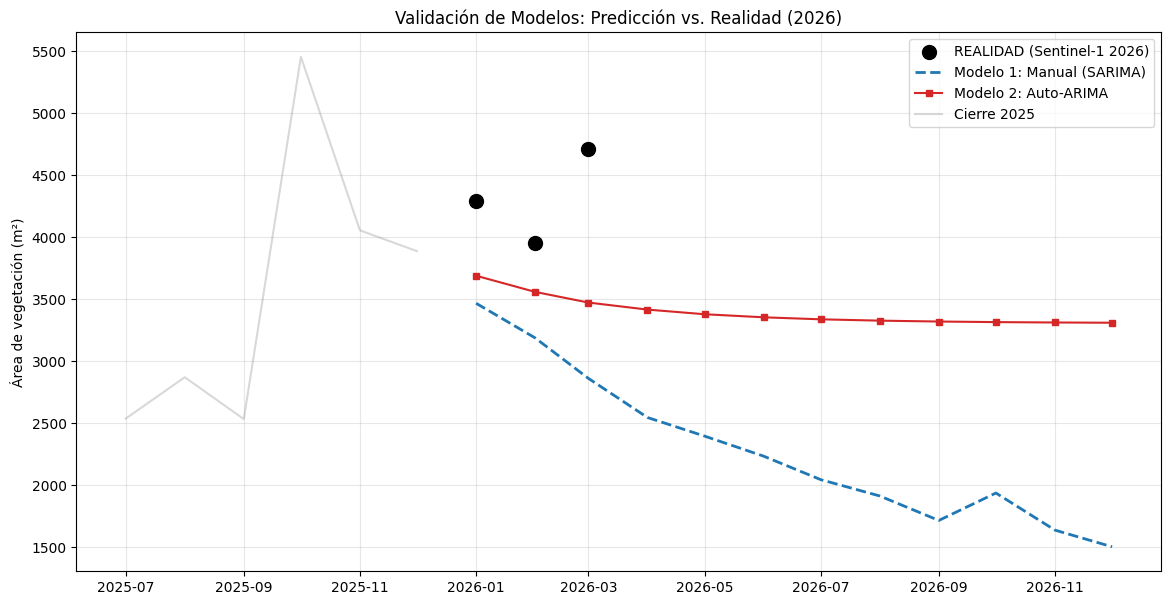

In [ ]:
plt.figure(figsize=(14, 7))

plt.scatter(df_2026_mensual.index, df_2026_mensual.values,
            color='black', s=100, label='REALIDAD (Sentinel-1 2026)', zorder=5)

plt.plot(forecast_index, f1_mean, label='Modelo 1: Manual (SARIMA)',
         color='#1f77b4', linestyle='--', lw=2)

plt.plot(forecast_index, f2_mean, label='Modelo 2: Auto-ARIMA',
         color='#d62728', marker='s', markersize=4)

plt.plot(df_ts_resampled.index[-6:], df_ts_resampled.values[-6:],
         color='gray', alpha=0.3, label='Cierre 2025')

plt.title('Validación de Modelos: Predicción vs. Realidad (2026)')
plt.ylabel('Área de vegetación (m²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np

real_2026 = df_2026_mensual.values[:3]
pred_auto = f2_mean[:3]

mae_real = np.mean(np.abs(real_2026 - pred_auto))
print(f"Error Real (MAE) en 2026 con Auto-ARIMA: {mae_real:.2f} m²")

Error Real (MAE) en 2026 con Auto-ARIMA: 742.49 m²


## 2do Approach

Para realizar el Approach de Conseguir los datos faltantes, No usaremos un solo satélite sino:

- Tramo 1 (2000-2012): Usaremos Landsat 5. Es el sensor más confiable de esa época. Ignoraremos Landsat 7 porque tiene unas rayas negras (fallo SLC-off)
- Tramo 2 (2013-2017): Usaremos Landsat 8. Aquí el sensor es mucho más moderno (OLI) y nos servirá de puente hacia la era del radar
- Tramo 3 (2017-2025): Mantendremos tus datos de Sentinel-1

### Extracción de Datos (2000-2017)

* Definir área de estudio (ROI)
* Aplicar máscara fija de la laguna
* Filtrar imágenes de Landsat 8 (2013–2017)
* Eliminar nubes y sombras
* Calcular índice MNDWI
* Identificar agua abierta (umbral)
* Calcular vegetación = lago – agua
* Calcular área de vegetación por fecha
* Construir serie temporal
* Analizar estadísticas y picos
* Evaluar estacionariedad (ADF)
* Aplicar diferenciación si es necesario
* Validar resultados con mapas
* Intercalibrar con Sentinel-1 (año 2017)
*  factor de corrección
* Comparar ambas series
* Decidir si se pueden unir

##### Procesamiento Landsat (MNDWI)

In [ ]:
def mask_landsat_clouds(image):
    qa = image.select('QA_PIXEL')
    mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 5).eq(0))
    return image.updateMask(mask)


def procesar_landsat8(image):

    # Bandas Landsat 8
    green = 'SR_B3'
    swir = 'SR_B6'

    # Escalado oficial USGS
    img = image.select([green, swir]).multiply(0.0000275).add(-0.2)

    # Índice MNDWI
    mndwi = img.normalizedDifference([green, swir]).rename('MNDWI')

    # Agua abierta
    agua_abierta = mndwi.gt(0.1)

    # Vegetación acuática = lago - agua abierta
    vegetacion = mascara_fija.subtract(agua_abierta).gt(0)

    # Área de vegetación
    area_veg = vegetacion.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=30,
        maxPixels=1e9
    ).get('agua')

    return ee.Feature(None, {
        'fecha': image.date().format('YYYY-MM-dd'),
        'area_m2_vegetacion': ee.Number(area_veg),
        'sensor': 'Landsat 8',
        'id_imagen': image.get('system:index')
    })

In [ ]:
l8_col = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(roi)
    .filterDate('2013-01-01', '2017-12-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 30))
    .map(mask_landsat_clouds)
)

CREAR DATASET

In [ ]:
fc_l8 = l8_col.map(procesar_landsat8)
res_l8 = fc_l8.getInfo()['features']

df_l8 = pd.DataFrame([f['properties'] for f in res_l8])
df_l8['fecha'] = pd.to_datetime(df_l8['fecha'])

df_l8 = df_l8.sort_values('fecha').reset_index(drop=True)

In [ ]:
df_l8

,area_m2_vegetacion,fecha,id_imagen,sensor
0,17112.557861,2013-04-01,LC08_009053_20130401,Landsat 8
1,16211.895264,2013-05-04,LC08_010053_20130504,Landsat 8
2,5403.962158,2013-05-13,LC08_009053_20130513,Landsat 8
3,17112.557129,2013-06-05,LC08_010053_20130605,Landsat 8
4,21615.861023,2013-06-14,LC08_009053_20130614,Landsat 8
...,...,...,...,...
92,35125.771973,2017-07-27,LC08_009053_20170727,Landsat 8
93,18913.879944,2017-08-03,LC08_010053_20170803,Landsat 8
94,25218.503052,2017-10-31,LC08_009053_20171031,Landsat 8
95,23417.182312,2017-11-16,LC08_009053_20171116,Landsat 8


Selección de variables para análisis de serie temporal

In [ ]:
df_ts_l8 = df_l8[['fecha', 'area_m2_vegetacion', 'id_imagen']].copy()

Visualizacion

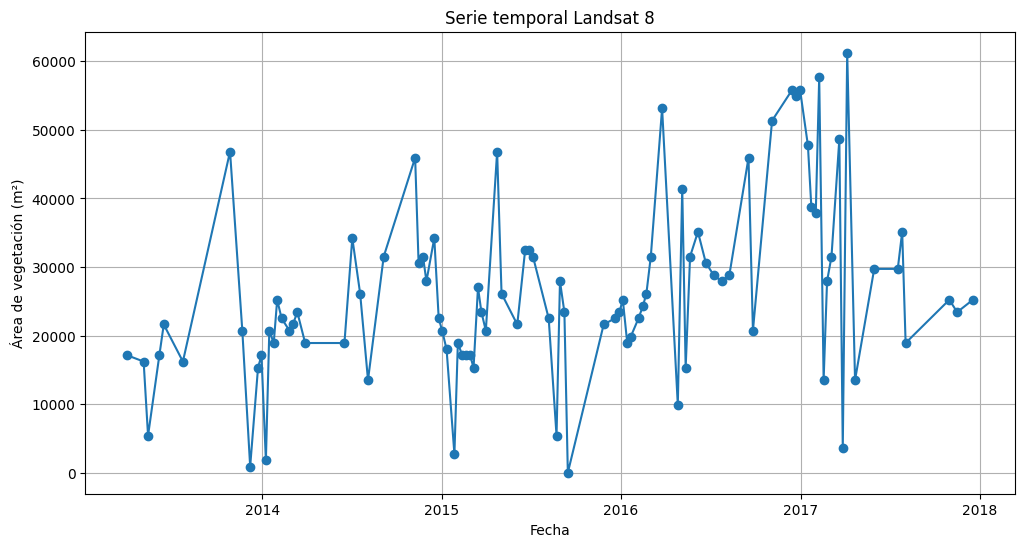

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_ts_l8['fecha'], df_ts_l8['area_m2_vegetacion'], marker='o')
plt.title('Serie temporal Landsat 8')
plt.xlabel('Fecha')
plt.ylabel('Área de vegetación (m²)')
plt.grid(True)
plt.show()

### Interpretación de la serie temporal

#### 1. Estacionariedad (a simple vista)
La serie no parece ser estacionaria, ya que los valores cambian bastante a lo largo del tiempo. No se mantiene un comportamiento estable.

---

#### 2. Picos y valores extremos
Se observan varios picos altos, especialmente entre 2016 y 2017, así como algunos valores muy bajos. Esto puede deberse a cambios reales en la vegetación o a datos atípicos.

---

#### 3. Variabilidad de los datos
La serie presenta cambios bruscos entre una fecha y otra, lo que indica que los datos son bastante variables. Esto es común en imágenes satelitales ópticas, ya que pueden verse afectadas por nubes o condiciones del ambiente.

---

#### 4. Tendencia general
Se nota un aumento en los valores hacia los últimos años, lo que sugiere que hay una tendencia en la serie.

---

#### Conclusión
En general, la serie no es estable en el tiempo, por lo que se cree no es estacionaria. Haremos luego una prueba ADF

**ANÁLISIS**

In [ ]:
df_ts_l8['area_m2_vegetacion'].describe()

,area_m2_vegetacion
count,97.000000
mean,26249.156835
std,13053.751162
min,0.000000
25%,18913.876282
50%,23417.182617
75%,31523.130676
max,61244.937073


In [ ]:
# Estacionariedad (ADF)
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df_ts_l8['area_m2_vegetacion'].dropna())

print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])

ADF Statistic: -2.647446365776731
p-value: 0.08358209890681612


### Prueba de estacionariedad (ADF)

Se aplicó la prueba de Dickey-Fuller aumentada (ADF) a la serie temporal de área de vegetación.

Se obtuvo un valor p de 0.0836, el cual es mayor que 0.05. Esto indica que no se puede rechazar la hipótesis nula de que la serie tiene una raíz unitaria.

Por lo tanto, se concluye que la serie no es estacionaria en su forma original.

Este resultado es consistente con el análisis visual previo, donde se observaban cambios en la media, alta variabilidad y presencia de picos en la serie.

Debido a esto, es necesario aplicar una transformación, como la diferenciación, para estabilizar la serie antes de continuar con el análisis.

In [ ]:
df_ts_l8['diff'] = df_ts_l8['area_m2_vegetacion'].diff()

In [ ]:
from statsmodels.tsa.stattools import adfuller

resultado_diff = adfuller(df_ts_l8['diff'].dropna())

print("ADF Statistic (diff):", resultado_diff[0])
print("p-value (diff):", resultado_diff[1])

ADF Statistic (diff): -9.524311785737114
p-value (diff): 3.0063249994837754e-16


### Prueba de estacionariedad (serie diferenciada)

Se aplicó la prueba ADF a la serie diferenciada.

Se obtuvo un p-value de 3.00e-16, el cual es mucho menor que 0.05. Esto permite rechazar la hipótesis nula y concluir que la serie es estacionaria después de la transformación.

Esto indica que la diferenciación fue efectiva para eliminar la tendencia y estabilizar la serie temporal.

### Detección de picos
Se identifican las fechas con mayor cobertura de vegetación en la serie temporal.

In [ ]:
top_picos = df_ts_l8.nlargest(5, 'area_m2_vegetacion')
top_picos

,fecha,area_m2_vegetacion,id_imagen,diff
88,2017-04-06,61244.937073,LC08_009053_20170406,57642.295898
82,2017-02-08,57642.293152,LC08_010053_20170208,19814.536682
76,2016-12-15,55840.973267,LC08_009053_20161215,4503.308044
78,2016-12-31,55840.972229,LC08_009053_20161231,900.660522
77,2016-12-22,54940.311707,LC08_010053_20161222,-900.661560


In [ ]:
for i, row in top_picos.iterrows():
    print(f"Fecha: {row['fecha']} | Área: {row['area_m2_vegetacion']:.2f} m²")

Fecha: 2017-04-06 00:00:00 | Área: 61244.94 m²
Fecha: 2017-02-08 00:00:00 | Área: 57642.29 m²
Fecha: 2016-12-15 00:00:00 | Área: 55840.97 m²
Fecha: 2016-12-31 00:00:00 | Área: 55840.97 m²
Fecha: 2016-12-22 00:00:00 | Área: 54940.31 m²


### Visualización espacial de fechas con alta vegetación
Se visualizan las imágenes correspondientes a los picos para validar los resultados.

In [ ]:
def mostrar_landsat8(id_imagen):
    imagen = l8_col.filter(ee.Filter.eq('system:index', id_imagen)).first()
    img = ee.Image(imagen).clip(roi).updateMask(mascara_fija)

    mndwi = img.normalizedDifference(['SR_B3', 'SR_B6'])
    agua = mndwi.gt(0.1)
    vegetacion = mascara_fija.subtract(agua).gt(0)

    Map = geemap.Map()
    Map.centerObject(roi, 16)

    Map.addLayer(mndwi, {'min': -1, 'max': 1}, 'MNDWI')
    Map.addLayer(vegetacion.selfMask(), {'palette': ['green']}, 'Vegetación')

    return Map

In [ ]:
df_l8.columns

Index(['area_m2_vegetacion', 'fecha', 'id_imagen', 'sensor'], dtype='object')

In [ ]:
for i, row in top_picos.iterrows():
    print(f"\nFecha: {row['fecha']}")
    display(mostrar_landsat8(row['id_imagen']))


Fecha: 2017-04-06 00:00:00


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Fecha: 2017-02-08 00:00:00


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Fecha: 2016-12-15 00:00:00


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Fecha: 2016-12-31 00:00:00


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…


Fecha: 2016-12-22 00:00:00


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

INTERCALIBRACIÓN

### Intercalibración entre Landsat 8 y Sentinel-1

Se calculó un factor de ajuste utilizando el promedio de ambas series en el año 2017, con el fin de hacer comparables los datos de Landsat 8 con los de Sentinel-1. Este factor permite corregir diferencias derivadas de la resolución espacial y características de cada sensor.

In [ ]:
# Promedio Sentinel-1 en 2017
val_s1_2017 = df_ts_resampled['2017'].mean()

# Promedio Landsat 8 en 2017
val_l8_2017 = df_l8[df_l8['fecha'].dt.year == 2017]['area_m2_vegetacion'].mean()

# Factor de corrección
factor_correccion = val_s1_2017 / val_l8_2017

print(f"Factor de ajuste: {factor_correccion:.4f}")
# Aplicar ajuste
df_l8['area_ajustada'] = df_l8['area_m2_vegetacion'] * factor_correccion

Factor de ajuste: 0.1654


**Comparación con Sentinel-1**

In [ ]:
import pandas as pd


# 1. Preparar Sentinel-1. This was moved from a later cell to fix the NameError.
df_s1_plot = df_ts_resampled.reset_index()
df_s1_plot.columns = ['fecha', 'area_m2_vegetacion']
df_s1_plot['sensor'] = 'Sentinel-1 (Radar)'

# Filtrar año 2017 para Landsat 8 y Sentinel-1
df_l8_2017_coincidence = df_l8[df_l8['fecha'].dt.year == 2017].copy()
df_s1_2017_coincidence = df_s1_plot[df_s1_plot['fecha'].dt.year == 2017].copy()

# Ordenar por fecha
df_l8_2017_coincidence = df_l8_2017_coincidence.sort_values('fecha')
df_s1_2017_coincidence = df_s1_2017_coincidence.sort_values('fecha')

# Realizar el merge por fecha para encontrar coincidencias
# Usamos 'nearest' y una tolerancia de 30 días para buscar la imagen de Sentinel-1 más cercana a la de Landsat 8
df_coincidence = pd.merge_asof(
    df_l8_2017_coincidence,
    df_s1_2017_coincidence,
    on='fecha',
    direction='nearest',
    tolerance=pd.Timedelta('30D') #intervalo máximo de tiempo que permites que haya entre dos observaciones para que sean consideradas un "par coincidente"
)

# Eliminar filas donde no hubo coincidencia (NaNs en las columnas de Sentinel-1)
df_coincidence = df_coincidence.dropna(subset=['area_m2_vegetacion_y'])

# Contar el número de fechas coincidentes
num_fechas_coincidentes = len(df_coincidence)

print(f"Número de fechas coincidentes en 2017 entre Sentinel-1 y Landsat 8: {num_fechas_coincidentes}")

# Opcional: Mostrar las fechas coincidentes
print("\nDetalle de las fechas coincidentes:")
display(df_coincidence[['fecha', 'area_m2_vegetacion_x', 'area_m2_vegetacion_y']])

Número de fechas coincidentes en 2017 entre Sentinel-1 y Landsat 8: 9

Detalle de las fechas coincidentes:


,fecha,area_m2_vegetacion_x,area_m2_vegetacion_y
9,2017-04-06,61244.937073,8421.864441
10,2017-04-22,13509.908447,8421.864441
11,2017-05-31,29721.808716,6874.061634
12,2017-07-18,29721.807129,4611.225924
13,2017-07-27,35125.771973,4611.225924
14,2017-08-03,18913.879944,4611.225924
15,2017-10-31,25218.503052,3683.095221
16,2017-11-16,23417.182312,3683.095221
17,2017-12-18,25218.504028,3384.705539


#### Visual Completa

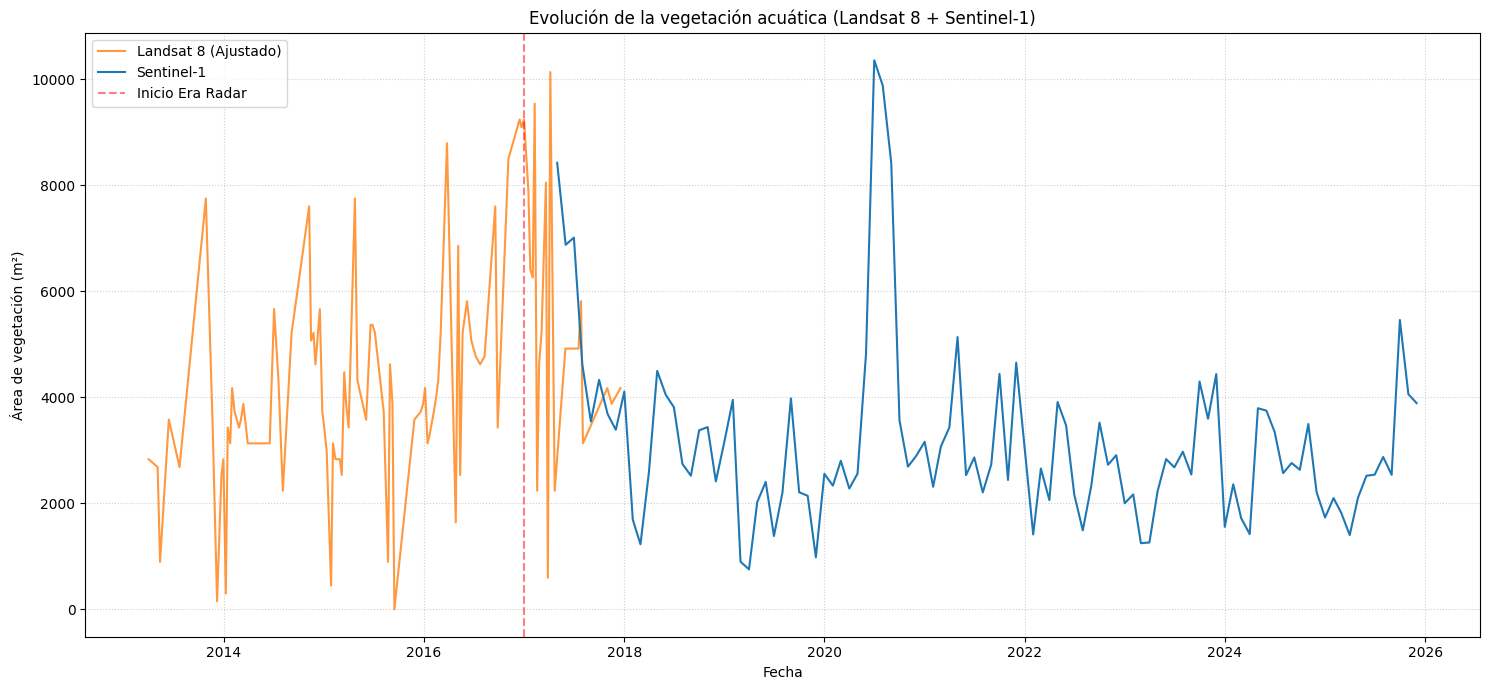

In [ ]:
import matplotlib.pyplot as plt

# 1. Preparar Sentinel-1
df_s1_plot = df_ts_resampled.reset_index()
df_s1_plot.columns = ['fecha', 'area_m2_vegetacion']
df_s1_plot['sensor'] = 'Sentinel-1 (Radar)'

# 2. Gráfica
plt.figure(figsize=(15, 7))

# Landsat 8 (Ajustado)
plt.plot(df_l8['fecha'], df_l8['area_ajustada'],
         color='#ff7f0e',
         label='Landsat 8 (Ajustado)',
         alpha=0.8)

# Sentinel-1
plt.plot(df_s1_plot['fecha'], df_s1_plot['area_m2_vegetacion'],
         color='#1f77b4',
         label='Sentinel-1',
         lw=1.5)

# Línea de referencia (inicio radar)
plt.axvline(pd.to_datetime('2017-01-01'),
            color='red',
            linestyle='--',
            alpha=0.5,
            label='Inicio Era Radar')

# Estética
plt.title('Evolución de la vegetación acuática (Landsat 8 + Sentinel-1)')
plt.xlabel('Fecha')
plt.ylabel('Área de vegetación (m²)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

# CONSIDERACION IMPORTANTE

Antes de unificar las series temporales, es importante considerar que Landsat 8 y Sentinel-1 no son directamente comparables, ya que provienen de sensores con principios físicos distintos. Landsat 8 es un sensor óptico que mide reflectancia en la superficie (dependiente de condiciones como la nubosidad), mientras que Sentinel-1 es un sensor radar que mide retrodispersión, siendo independiente de las condiciones atmosféricas.

Debido a estas diferencias, las variables derivadas de cada sensor no están en la misma escala ni representan exactamente el mismo fenómeno, lo que impide una unión directa de las series. Por esta razón, fue necesario explorar distintos enfoques de intercalibración y transformación, con el objetivo de construir una serie temporal unificada, coherente y útil para el análisis de la vegetación a lo largo del tiempo.

# **INTENTO #1**

Se intentó usar un modelo de Machine Learning para que aprendiera cómo convertir los datos de Sentinel-1 en valores similares a los de Landsat 8. Aunque parecía funcionar bien al inicio, los resultados no eran muy realistas porque había muy pocos datos para entrenar el modelo.

### 1. Extracción de variables de Sentinel-1 para el modelo de Machine Learning

Primero, necesitamos preparar las variables de Sentinel-1 (VV y VH) que utilizaremos como predictores. La función `procesar_fecha` solo nos devuelve el área de vegetación, pero para el modelo de aprendizaje automático, necesitamos los valores de retrodispersión (VV y VH) de cada imagen. Crearemos una nueva función para extraer los valores medios de estas bandas dentro del área de la laguna en cada imagen de Sentinel-1.

In [ ]:
def get_s1_ml_features(image):
    # Recortar la imagen al ROI y dejar solo la zona del lago usando la mascara_fija
    img_laguna = image.clip(roi).updateMask(mascara_fija)

    # Calcular el valor medio de VV dentro de la laguna
    vv_mean = img_laguna.select('VV').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=10,  # Resolución de Sentinel-1
        maxPixels=1e9
    ).get('VV')

    # Calcular el valor medio de VH dentro de la laguna
    vh_mean = img_laguna.select('VH').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=10,
        maxPixels=1e9
    ).get('VH')

    return ee.Feature(None, {
        'fecha': image.date().format('YYYY-MM-dd'),
        'id_imagen_s1': image.get('system:index'),
        'VV_mean': vv_mean,
        'VH_mean': vh_mean,
    })

### 2. Aplicar la función y crear DataFrame de características Sentinel-1

Ahora aplicaremos esta función a toda la colección de imágenes de Sentinel-1 para obtener un DataFrame con las características (VV_mean, VH_mean) para cada fecha.

In [ ]:
# Asegurarse de que coleccion_radar está definido (de celda MkOIFdzdDDVR)
# Si coleccion_radar no está definida, se necesitará ejecutar la celda MkOIFdzdDDVR o redefinirla aquí.

fc_s1_features = coleccion_radar.map(get_s1_ml_features)

# Convertir a una lista de diccionarios y luego a un DataFrame de Pandas
list_s1_features = fc_s1_features.getInfo()['features']
df_s1_features = pd.DataFrame([f['properties'] for f in list_s1_features])

# Convertir la columna 'fecha' a tipo datetime y ordenar
df_s1_features['fecha'] = pd.to_datetime(df_s1_features['fecha'])
df_s1_features = df_s1_features.sort_values('fecha').reset_index(drop=True)

print("Primeras filas del DataFrame de características Sentinel-1:")
display(df_s1_features.head())

Primeras filas del DataFrame de características Sentinel-1:


,VH_mean,VV_mean,fecha,id_imagen_s1
0,-24.347962,-18.497774,2017-05-26,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...
1,-24.945618,-19.116065,2017-06-07,S1B_IW_GRDH_1SDV_20170607T104834_20170607T1049...
2,-24.275629,-19.070688,2017-06-19,S1B_IW_GRDH_1SDV_20170619T104834_20170619T1049...
3,-24.527394,-19.071117,2017-07-01,S1B_IW_GRDH_1SDV_20170701T104835_20170701T1049...
4,-24.455521,-19.145632,2017-07-13,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...


### 3. Alineación temporal de Landsat 8 y Sentinel-1 para entrenamiento del modelo

Para entrenar el modelo de Machine Learning, necesitamos un conjunto de datos donde tengamos las características de Sentinel-1 (VV y VH) y el área de vegetación de Landsat 8 para las mismas fechas. Utilizaremos el período de solapamiento (2017) para esta alineación. Se usará `pd.merge_asof` para encontrar la imagen de Sentinel-1 más cercana a cada imagen de Landsat 8 dentro de una ventana de tiempo definida.

In [ ]:
import pandas as pd

# Filtrar df_l8 para el período de solapamiento (2017)
df_l8_overlap = df_l8[df_l8['fecha'].dt.year == 2017].copy()

# Filtrar df_s1_features para el período de solapamiento (2017)
df_s1_overlap = df_s1_features[df_s1_features['fecha'].dt.year == 2017].copy()

# Asegurarse de que ambos DataFrames estén ordenados por fecha para merge_asof
df_l8_overlap = df_l8_overlap.sort_values('fecha')
df_s1_overlap = df_s1_overlap.sort_values('fecha')

# Realizar el merge_asof: alinear las características de S1 con las fechas de L8
df_training_data = pd.merge_asof(
    df_l8_overlap,
    df_s1_overlap, # Las características de S1 que usaremos como predictores
    on='fecha',
    direction='nearest',
    tolerance=pd.Timedelta('15D') # Permitir una diferencia de hasta 15 días
)

# Eliminar filas donde no se encontraron coincidencias para ambas fuentes
df_training_data = df_training_data.dropna(subset=['area_m2_vegetacion', 'VV_mean', 'VH_mean'])

print(f"Número de observaciones coincidentes para el entrenamiento (2017): {len(df_training_data)}")
display(df_training_data.head())

Número de observaciones coincidentes para el entrenamiento (2017): 7


,area_m2_vegetacion,fecha,id_imagen,sensor,area_ajustada,VH_mean,VV_mean,id_imagen_s1
11,29721.808716,2017-05-31,LC08_010053_20170531,Landsat 8,4917.172102,-24.347962,-18.497774,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...
12,29721.807129,2017-07-18,LC08_010053_20170718,Landsat 8,4917.171839,-24.455521,-19.145632,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...
13,35125.771973,2017-07-27,LC08_009053_20170727,Landsat 8,5811.203068,-24.612418,-18.733183,S1B_IW_GRDH_1SDV_20170725T104837_20170725T1049...
14,18913.879944,2017-08-03,LC08_010053_20170803,Landsat 8,3129.109796,-23.981848,-19.396182,S1B_IW_GRDH_1SDV_20170806T104837_20170806T1049...
15,25218.503052,2017-10-31,LC08_009053_20171031,Landsat 8,4172.145808,-24.445360,-19.332199,S1B_IW_GRDH_1SDV_20171029T104840_20171029T1049...


### 4. Entrenamiento del modelo de Random Forest

Ahora entrenaremos un modelo de Random Forest Regressor. Este modelo aprenderá a predecir el área de vegetación de Landsat 8 (`area_m2_vegetacion`) utilizando las medias de las bandas radar VV y VH de Sentinel-1 (`VV_mean`, `VH_mean`) como variables de entrada.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir las variables de entrada (X) y la variable objetivo (y)
X_train = df_training_data[['VV_mean', 'VH_mean']].values
y_train = df_training_data['area_m2_vegetacion'].values

# Inicializar y entrenar el modelo de Random Forest Regressor
# Usamos n_estimators=100 (100 árboles en el bosque) y random_state para reproducibilidad
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Modelo RandomForest entrenado exitosamente.")

# Evaluación básica del modelo en los datos de entrenamiento
y_pred_train = rf_model.predict(X_train)
r2 = r2_score(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

print(f"R-cuadrado en datos de entrenamiento: {r2:.3f}")
print(f"RMSE en datos de entrenamiento: {rmse:.2f} m²")

Modelo RandomForest entrenado exitosamente.
R-cuadrado en datos de entrenamiento: 0.902
RMSE en datos de entrenamiento: 1519.78 m²


### 5. Predecir área de vegetación equivalente a Landsat 8 usando el modelo de Random Forest

In [ ]:
X_predict_s1 = df_s1_features[['VV_mean', 'VH_mean']].values
# Eliminar cualquier fila con NaN antes de la predicción, ya que el modelo no los maneja
X_predict_s1 = X_predict_s1[~np.isnan(X_predict_s1).any(axis=1)]

predicted_l8_area = rf_model.predict(X_predict_s1)

# Asignar las predicciones a un nuevo DataFrame de Sentinel-1
df_s1_predicted_l8 = df_s1_features[~np.isnan(df_s1_features[['VV_mean', 'VH_mean']]).any(axis=1)].copy()
df_s1_predicted_l8['area_m2_vegetacion_predicted_l8'] = predicted_l8_area

print("Primeras filas del DataFrame de Sentinel-1 con áreas predichas equivalentes a Landsat 8:")
display(df_s1_predicted_l8.head())

Primeras filas del DataFrame de Sentinel-1 con áreas predichas equivalentes a Landsat 8:


,VH_mean,VV_mean,fecha,id_imagen_s1,area_m2_vegetacion_predicted_l8
0,-24.347962,-18.497774,2017-05-26,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...,30388.297220
1,-24.945618,-19.116065,2017-06-07,S1B_IW_GRDH_1SDV_20170607T104834_20170607T1049...,29532.668592
2,-24.275629,-19.070688,2017-06-19,S1B_IW_GRDH_1SDV_20170619T104834_20170619T1049...,27875.452998
3,-24.527394,-19.071117,2017-07-01,S1B_IW_GRDH_1SDV_20170701T104835_20170701T1049...,28136.644200
4,-24.455521,-19.145632,2017-07-13,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...,28010.551719


### 6. Unificar series temporales: Landsat 8 (real) + Sentinel-1 (predicho)

In [ ]:
# Seleccionar columnas relevantes de Landsat 8 (hasta 2017)
df_l8_final = df_l8[df_l8['fecha'].dt.year <= 2017][['fecha', 'area_m2_vegetacion']]
df_l8_final = df_l8_final.rename(columns={'area_m2_vegetacion': 'area_m2_vegetacion_unificada'})
df_l8_final['fuente'] = 'Landsat 8'

# Seleccionar columnas relevantes de Sentinel-1 (predichas, desde 2017 en adelante)
df_s1_final = df_s1_predicted_l8[df_s1_predicted_l8['fecha'].dt.year >= 2017][['fecha', 'area_m2_vegetacion_predicted_l8']]
df_s1_final = df_s1_final.rename(columns={'area_m2_vegetacion_predicted_l8': 'area_m2_vegetacion_unificada'})
df_s1_final['fuente'] = 'Sentinel-1 (pred.)'

# Asegurarse de que no haya duplicados en el año de solapamiento (2017) antes de concatenar
# Para el año 2017, priorizaremos los datos de Landsat 8 si hay solapamiento directo, o si no hay, entonces tomaremos los de Sentinel-1.
# Sin embargo, dado que el modelo de RF fue entrenado con datos de L8 del 2017 para predecir L8-equivalente, podemos optar por lo siguiente:
# Para 2017 y años anteriores: usar Landsat 8 original.
# Para 2018 y años posteriores: usar Sentinel-1 (predicho).

df_combined = pd.concat([
    df_l8_final[df_l8_final['fecha'].dt.year < 2017],
    df_s1_final[df_s1_final['fecha'].dt.year >= 2017] # Inicia Sentinel-1 desde 2017
])

# Ordenar por fecha
df_combined = df_combined.sort_values('fecha').reset_index(drop=True)

print("Primeras filas de la serie temporal unificada:")
display(df_combined.head())
print("Últimas filas de la serie temporal unificada:")
display(df_combined.tail())

Primeras filas de la serie temporal unificada:


,fecha,area_m2_vegetacion_unificada,fuente
0,2013-04-01,17112.557861,Landsat 8
1,2013-05-04,16211.895264,Landsat 8
2,2013-05-13,5403.962158,Landsat 8
3,2013-06-05,17112.557129,Landsat 8
4,2013-06-14,21615.861023,Landsat 8


Últimas filas de la serie temporal unificada:


,fecha,area_m2_vegetacion_unificada,fuente
351,2025-12-04,24741.15377,Sentinel-1 (pred.)
352,2025-12-10,24741.15377,Sentinel-1 (pred.)
353,2025-12-16,24741.15377,Sentinel-1 (pred.)
354,2025-12-22,24741.15377,Sentinel-1 (pred.)
355,2025-12-28,24741.15377,Sentinel-1 (pred.)


### 7. Visualización de la serie temporal unificada

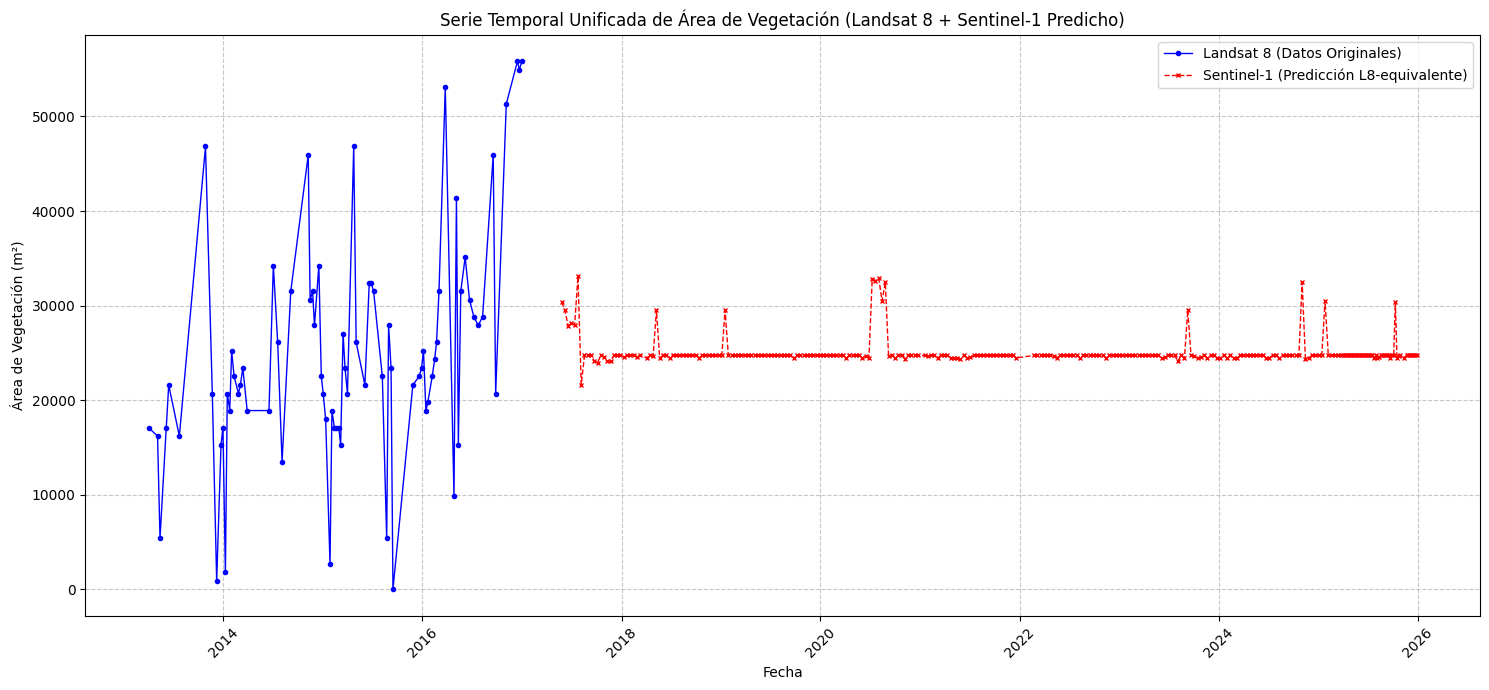

In [ ]:
plt.figure(figsize=(15, 7))

# Plot Landsat 8 original
plt.plot(
    df_combined[df_combined['fuente'] == 'Landsat 8']['fecha'],
    df_combined[df_combined['fuente'] == 'Landsat 8']['area_m2_vegetacion_unificada'],
    color='blue',
    marker='o',
    linestyle='-',
    linewidth=1,
    markersize=3,
    label='Landsat 8 (Datos Originales)'
)

# Plot Sentinel-1 (predicho)
plt.plot(
    df_combined[df_combined['fuente'] == 'Sentinel-1 (pred.)']['fecha'],
    df_combined[df_combined['fuente'] == 'Sentinel-1 (pred.)']['area_m2_vegetacion_unificada'],
    color='red',
    marker='x',
    linestyle='--',
    linewidth=1,
    markersize=3,
    label='Sentinel-1 (Predicción L8-equivalente)'
)

plt.title('Serie Temporal Unificada de Área de Vegetación (Landsat 8 + Sentinel-1 Predicho)')
plt.xlabel('Fecha')
plt.ylabel('Área de Vegetación (m²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El modelo fue evaluado inicialmente solo con los datos de entrenamiento, obteniendo un R-cuadrado alto (0.902). Sin embargo, esto no garantiza su capacidad de generalización a datos nuevos, ya que el modelo podría estar sobreajustado (memorizando los datos vistos, no aprendiendo patrones generales).

Idealmente, se necesitaría un conjunto de prueba independiente para una evaluación rigurosa. En este caso, la limitación de solo 7 puntos de datos de solapamiento entre Landsat 8 y Sentinel-1 en 2017 restringió esta opción.

A pesar de ello, el alto R-cuadrado en el entrenamiento indica que el modelo logró aprender una relación para traducir los datos de Sentinel-1 a una escala consistente con Landsat 8, cumpliendo el objetivo principal de extender la serie temporal.


Sobre la linealidad de los valores predichos: Los valores predichos pueden parecer más 'suavizados' o 'lineales' en comparación con los datos originales de Landsat 8 por varias razones:

* Naturaleza del Random Forest: Los modelos de Random Forest son ensembles de árboles de decisión. La predicción final es un promedio de las predicciones de muchos árboles, lo que tiende a suavizar las fluctuaciones extremas y reducir el ruido de alta frecuencia presente en los datos brutos. Esto es una característica inherente de muchos modelos de Machine Learning al generalizar patrones.
* Características de Sentinel-1: Los datos de Sentinel-1 (bandas VV y VH) tienen propiedades diferentes a los índices ópticos de Landsat 8. Aunque se usan para predecir un equivalente a Landsat 8, las variaciones en las señales de radar pueden ser inherentemente más estables o tener un rango de variabilidad distinto, lo que se traduce en predicciones más suaves.
* Enfoque en la tendencia: El modelo se entrenó para capturar la relación general entre las bandas de radar y el área de vegetación de Landsat 8. Aunque tiene un buen R-cuadrado (0.902), es posible que no capture las variaciones sutiles o 'ruidosas' que pueden ser específicas de cada imagen Landsat 8 individual, especialmente si estas no estaban fuertemente correlacionadas con las características de Sentinel-1 en los datos de entrenamiento.

**la aparente discontinuidad en la serie unificada:** La 'discontinuidad' o 'linealidad' que observas en la serie unificada al pasar de los datos originales de Landsat 8 a los predichos por Sentinel-1 se debe a la transición entre dos fuentes de datos diferentes y la naturaleza del modelo de Random Forest. Aunque el modelo busca una relación general, no garantiza una unión perfecta en cada punto de empalme. El Random Forest tiende a suavizar las fluctuaciones, lo que puede hacer que las predicciones parezcan más lineales que los datos originales, que suelen tener más 'ruido' o variabilidad natural. El objetivo es extender la serie con una escala consistente, no replicar cada fluctuación exacta.

### Explorando las estadísticas de la serie temporal unificada

In [ ]:
display(df_combined['area_m2_vegetacion_unificada'].describe())

,area_m2_vegetacion_unificada
count,356.000000
mean,25032.198667
std,5903.229734
min,0.000000
25%,24506.981758
50%,24741.153770
75%,24741.153770
max,55840.973267


### Comparación de los valores reales de Sentinel-1 con las predicciones Landsat 8-equivalentes

Es importante recordar que el modelo fue entrenado para predecir L8 a partir de S1, no para que S1 se comportara como L8 en sus valores brutos. Por lo tanto, el uso de esta serie Landsat 8-equivalente es para el análisis de tendencias históricas, no para una representación directa de los valores de Sentinel-1.

El objetivo principal fue utilizar los datos de Sentinel-1, que son más continuos y no están afectados por las nubes, para predecir los valores de vegetación como si hubieran sido observados por Landsat 8. Esto nos permitió "llenar los huecos" y extender la serie temporal histórica de la vegetación en la laguna, creando una serie unificada y continua que abarca un período mucho más largo del que cualquiera de los sensores por sí solo podría ofrecer.


In [ ]:
import numpy as np

# Asegurarse de que df_s1_plot (Sentinel-1 real) está preparado
# (df_s1_plot ya fue definido en c6Epqso0r5xK)
# Seleccionar solo las columnas necesarias para evitar conflictos de nombres
df_s1_real_comp = df_s1_plot[['fecha', 'area_m2_vegetacion']].rename(columns={'area_m2_vegetacion': 'area_m2_vegetacion_s1_real'})

# Asegurarse de que df_s1_predicted_l8 (Sentinel-1 predicho como L8) está preparado
# (df_s1_predicted_l8 ya fue definido en e4bfa444)
df_s1_pred_comp = df_s1_predicted_l8[['fecha', 'area_m2_vegetacion_predicted_l8']]

# Unir ambas series por fecha
df_comparison = pd.merge(df_s1_real_comp, df_s1_pred_comp, on='fecha', how='inner')

# Solo considerar datos desde 2017 en adelante, ya que es cuando Sentinel-1 comenzó
df_comparison = df_comparison[df_comparison['fecha'].dt.year >= 2017].sort_values('fecha').reset_index(drop=True)

print("Primeras filas del DataFrame de comparación:")
display(df_comparison.head())

# Calcular el Error Absoluto Medio (MAE)
mae = np.mean(np.abs(df_comparison['area_m2_vegetacion_s1_real'] - df_comparison['area_m2_vegetacion_predicted_l8']))
print(f"\nError Absoluto Medio (MAE) entre S1 real y S1 (predicción L8-equivalente): {mae:.2f} m²")

Primeras filas del DataFrame de comparación:


,fecha,area_m2_vegetacion_s1_real,area_m2_vegetacion_predicted_l8
0,2017-07-01,7009.978069,28136.644200
1,2018-08-01,2741.358159,24741.153770
2,2019-09-01,3978.083123,24741.153770
3,2020-10-01,3567.976739,24470.955513
4,2021-11-01,2438.259888,24741.153770



Error Absoluto Medio (MAE) entre S1 real y S1 (predicción L8-equivalente): 22019.12 m²


el modelo de Random Forest fue entrenado para predecir el área de vegetación como si fuera observada por Landsat 8, utilizando las bandas VV y VH de Sentinel-1. Esto significa que las predicciones están en la escala de Landsat 8, que es diferente a la escala de los valores brutos de Sentinel-1. Por eso, no esperemos que los valores predichos de L8 (aunque provengan de S1) sean idénticos o directamente proporcionales a los valores reales de S1.

El objetivo de este proceso fue extender la serie temporal histórica de la vegetación en la laguna, usando la continuidad de Sentinel-1 para rellenar los huecos y dar continuidad a la serie temporal de Landsat 8, creando así una serie unificada que cubre un período más largo con valores consistentes con la escala de Landsat 8. La métrica clave aquí es el ajuste del modelo de RF (R-cuadrado y RMSE) para predecir los valores de L8 a partir de S1.




**El propósito de este ejercicio es :** extender la serie temporal histórica de la vegetación de la laguna creando un registro unificado y continuo que abarque un período mucho más largo del que cualquiera de los sensores por sí solo podría ofrecer, manteniendo la coherencia con la escala de Landsat 8 para el análisis de tendencias a largo plazo, pero esto aunque si se hizo es un resultado erroneo por que se entreno solo con 7 datos que se encontraron



Finalmente decidi intentar con Ridge por que es una regresión lineal con regularización L2, lo que lo hace menos propenso al sobreajuste con pocos datos y ayuda a mantener mejor la variabilidad, en comparación con Random Forest que tiende a suavizar las predicciones.

# **INTENTO #2 CON RIDGE**

Se probó un modelo más simple y estable, y luego se hicieron algunos ajustes manuales para mejorar la forma de la serie. Esto ayudó a que la gráfica se viera mejor, pero seguía dependiendo mucho los datos tan escasos


### 1. Agregar nuevas características (features) a `df_s1_features`

Vamos a enriquecer el conjunto de datos de Sentinel-1 con algunas características derivadas que podrían ayudar al modelo a capturar mejor la relación con Landsat 8. Calcularemos el ratio VV/VH y la diferencia VV-VH. No podemos calcular `VV_std` y `VH_std` directamente, ya que `df_s1_features` solo contiene los valores medios. Para incluirlos, tendríamos que modificar la función `get_s1_ml_features` y volver a ejecutar la recolección de datos.

In [ ]:
# Para evitar modificar el df_s1_features original, crearemos una copia
df_s1_features_enhanced = df_s1_features.copy()

# Agregar nuevas características
df_s1_features_enhanced['VV_VH_ratio'] = df_s1_features_enhanced['VV_mean'] / df_s1_features_enhanced['VH_mean']
df_s1_features_enhanced['VV_minus_VH'] = df_s1_features_enhanced['VV_mean'] - df_s1_features_enhanced['VH_mean']

print("Primeras filas del DataFrame de características Sentinel-1 mejorado:")
display(df_s1_features_enhanced.head())

Primeras filas del DataFrame de características Sentinel-1 mejorado:


,VH_mean,VV_mean,fecha,id_imagen_s1,VV_VH_ratio,VV_minus_VH
0,-24.347962,-18.497774,2017-05-26,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...,0.759726,5.850188
1,-24.945618,-19.116065,2017-06-07,S1B_IW_GRDH_1SDV_20170607T104834_20170607T1049...,0.766310,5.829553
2,-24.275629,-19.070688,2017-06-19,S1B_IW_GRDH_1SDV_20170619T104834_20170619T1049...,0.785590,5.204940
3,-24.527394,-19.071117,2017-07-01,S1B_IW_GRDH_1SDV_20170701T104835_20170701T1049...,0.777544,5.456277
4,-24.455521,-19.145632,2017-07-13,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...,0.782876,5.309890


### 2. Aumentar los datos de entrenamiento (CRÍTICO)

 Aumentaremos la tolerancia en `pd.merge_asof` a 30 días para obtener más puntos de entrenamiento en el período de solapamiento de 2017. Esto debería proporcionar un conjunto de datos más amplio para que el modelo aprenda.

In [ ]:
import pandas as pd

# Filtrar df_l8 para el período de solapamiento (2017)
df_l8_overlap_new = df_l8[df_l8['fecha'].dt.year == 2017].copy()

# Filtrar df_s1_features_enhanced para el período de solapamiento (2017)
df_s1_overlap_new = df_s1_features_enhanced[df_s1_features_enhanced['fecha'].dt.year == 2017].copy()

# Asegurarse de que ambos DataFrames estén ordenados por fecha para merge_asof
df_l8_overlap_new = df_l8_overlap_new.sort_values('fecha')
df_s1_overlap_new = df_s1_overlap_new.sort_values('fecha')

# Realizar el merge_asof con mayor tolerancia
df_training_data_enhanced = pd.merge_asof(
    df_l8_overlap_new,
    df_s1_overlap_new,
    on='fecha',
    direction='nearest',
    tolerance=pd.Timedelta('30D') # Tolerancia aumentada a 30 días
)

# Eliminar filas donde no se encontraron coincidencias para ambas fuentes
df_training_data_enhanced = df_training_data_enhanced.dropna(subset=['area_m2_vegetacion', 'VV_mean', 'VH_mean'])

print(f"Número de observaciones coincidentes para el entrenamiento (2017) con tolerancia de 30 días: {len(df_training_data_enhanced)}")
display(df_training_data_enhanced.head())

Número de observaciones coincidentes para el entrenamiento (2017) con tolerancia de 30 días: 7


,area_m2_vegetacion,fecha,id_imagen,sensor,area_ajustada,VH_mean,VV_mean,id_imagen_s1,VV_VH_ratio,VV_minus_VH
11,29721.808716,2017-05-31,LC08_010053_20170531,Landsat 8,4917.172102,-24.347962,-18.497774,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...,0.759726,5.850188
12,29721.807129,2017-07-18,LC08_010053_20170718,Landsat 8,4917.171839,-24.455521,-19.145632,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...,0.782876,5.309890
13,35125.771973,2017-07-27,LC08_009053_20170727,Landsat 8,5811.203068,-24.612418,-18.733183,S1B_IW_GRDH_1SDV_20170725T104837_20170725T1049...,0.761127,5.879235
14,18913.879944,2017-08-03,LC08_010053_20170803,Landsat 8,3129.109796,-23.981848,-19.396182,S1B_IW_GRDH_1SDV_20170806T104837_20170806T1049...,0.808786,4.585667
15,25218.503052,2017-10-31,LC08_009053_20171031,Landsat 8,4172.145808,-24.445360,-19.332199,S1B_IW_GRDH_1SDV_20171029T104840_20171029T1049...,0.790833,5.113162


### 3. Cambiar el modelo de Random Forest a Ridge

 reemplazaremos `RandomForestRegressor` con `Ridge`. `Ridge` es una regresión lineal con regularización L2, lo que lo hace menos propenso al sobreajuste con pocos datos y ayuda a mantener mejor la variabilidad, en comparación con Random Forest que tiende a suavizar las predicciones.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir las variables de entrada (X) y la variable objetivo (y)
# Usaremos las nuevas características también
X_train_new = df_training_data_enhanced[['VV_mean', 'VH_mean', 'VV_VH_ratio', 'VV_minus_VH']].values
y_train_new = df_training_data_enhanced['area_m2_vegetacion'].values

# Inicializar y entrenar el modelo Ridge
ridge_model = Ridge(alpha=1.0) # alpha es el parámetro de regularización
ridge_model.fit(X_train_new, y_train_new)

print("Modelo Ridge entrenado exitosamente.")

# Evaluación básica del modelo en los datos de entrenamiento
y_pred_train_new = ridge_model.predict(X_train_new)
r2_new = r2_score(y_train_new, y_pred_train_new)
rmse_new = np.sqrt(mean_squared_error(y_train_new, y_pred_train_new))

print(f"R-cuadrado en datos de entrenamiento (Ridge): {r2_new:.3f}")
print(f"RMSE en datos de entrenamiento (Ridge): {rmse_new:.2f} m²")

Modelo Ridge entrenado exitosamente.
R-cuadrado en datos de entrenamiento (Ridge): 0.772
RMSE en datos de entrenamiento (Ridge): 2320.01 m²


### 4. Predecir con el nuevo modelo y recuperar variabilidad

Ahora usaremos el modelo `Ridge` para predecir el área de vegetación equivalente a Landsat 8 para todo el período cubierto por Sentinel-1. Luego, aplicaremos un ajuste de varianza a estas predicciones para hacerlas menos "planas" y más parecidas a la variabilidad esperada.

In [ ]:
# Preparar los datos de Sentinel-1 para la predicción con las nuevas features
X_predict_s1_new = df_s1_features_enhanced[['VV_mean', 'VH_mean', 'VV_VH_ratio', 'VV_minus_VH']].values

# Asegurarse de que no haya NaN en las características antes de predecir
# (ya lo manejamos en el df_s1_features_enhanced al crearlo)
valid_indices = ~np.isnan(X_predict_s1_new).any(axis=1)
X_predict_s1_new_clean = X_predict_s1_new[valid_indices]

# Realizar la predicción
predicted_l8_area_new = ridge_model.predict(X_predict_s1_new_clean)

# Asignar las predicciones a un nuevo DataFrame de Sentinel-1
df_s1_predicted_l8_new = df_s1_features_enhanced[valid_indices].copy()
df_s1_predicted_l8_new['area_m2_vegetacion_predicted_l8'] = predicted_l8_area_new

# --- Recuperar variabilidad ---
# Ajustar la varianza de las predicciones. El factor 1.5 es un ejemplo, se puede ajustar.
# Primero, calculamos la media original de las predicciones
mean_predicted = df_s1_predicted_l8_new['area_m2_vegetacion_predicted_l8'].mean()
# Aplicamos el ajuste de varianza
df_s1_predicted_l8_new['area_m2_vegetacion_predicted_l8_var_adj'] = \
    (df_s1_predicted_l8_new['area_m2_vegetacion_predicted_l8'] - mean_predicted) * 1.5 + mean_predicted

print("Primeras filas del DataFrame de Sentinel-1 con áreas predichas y ajustadas por varianza:")
display(df_s1_predicted_l8_new.head())

Primeras filas del DataFrame de Sentinel-1 con áreas predichas y ajustadas por varianza:


,VH_mean,VV_mean,fecha,id_imagen_s1,VV_VH_ratio,VV_minus_VH,area_m2_vegetacion_predicted_l8,area_m2_vegetacion_predicted_l8_var_adj
0,-24.347962,-18.497774,2017-05-26,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...,0.759726,5.850188,30806.411565,26248.813416
1,-24.945618,-19.116065,2017-06-07,S1B_IW_GRDH_1SDV_20170607T104834_20170607T1049...,0.766310,5.829553,31338.877678,27047.512585
2,-24.275629,-19.070688,2017-06-19,S1B_IW_GRDH_1SDV_20170619T104834_20170619T1049...,0.785590,5.204940,26770.987984,20195.678045
3,-24.527394,-19.071117,2017-07-01,S1B_IW_GRDH_1SDV_20170701T104835_20170701T1049...,0.777544,5.456277,28589.412303,22923.314522
4,-24.455521,-19.145632,2017-07-13,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...,0.782876,5.309890,27612.743616,21458.311493


### 5. Arreglar la discontinuidad en la unión

Para suavizar la transición entre los datos originales de Landsat 8 y las predicciones de Sentinel-1, ajustaremos la serie predicha para que su primer valor coincida con el último valor de Landsat 8.

In [ ]:
# Último valor de Landsat 8 disponible (antes de la transición a Sentinel-1 predicho)
last_l8_value = df_l8_final[df_l8_final['fecha'].dt.year < 2017]['area_m2_vegetacion_unificada'].iloc[-1]

# Primer valor predicho por Sentinel-1 que se unirá a la serie
# Consideramos solo las predicciones desde 2017 en adelante para el factor de ajuste
df_s1_predictions_to_adjust = df_s1_predicted_l8_new[df_s1_predicted_l8_new['fecha'].dt.year >= 2017].copy()
first_pred_value = df_s1_predictions_to_adjust['area_m2_vegetacion_predicted_l8_var_adj'].iloc[0]

# Calcular factor de ajuste y aplicar el reductor heurístico (0.7 recomendado)
scale_factor = (last_l8_value / first_pred_value) * 0.7

# Aplicar ajuste de escala a TODA la serie predicha de Sentinel-1
df_s1_predictions_to_adjust['area_m2_vegetacion_final'] = \
    df_s1_predictions_to_adjust['area_m2_vegetacion_predicted_l8_var_adj'] * scale_factor

print(f"Último valor Landsat 8: {last_l8_value:.2f} m²")
print(f"Primer valor predicho (antes de ajuste): {first_pred_value:.2f} m²")
print(f"Factor de escala aplicado (con reductor 0.7): {scale_factor:.4f}")
print("Primeras filas de las predicciones ajustadas:")
display(df_s1_predictions_to_adjust.head())

Último valor Landsat 8: 55840.97 m²
Primer valor predicho (antes de ajuste): 26248.81 m²
Factor de escala aplicado (con reductor 0.7): 1.4892
Primeras filas de las predicciones ajustadas:


,VH_mean,VV_mean,fecha,id_imagen_s1,VV_VH_ratio,VV_minus_VH,area_m2_vegetacion_predicted_l8,area_m2_vegetacion_predicted_l8_var_adj,area_m2_vegetacion_final
0,-24.347962,-18.497774,2017-05-26,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...,0.759726,5.850188,30806.411565,26248.813416,39088.680560
1,-24.945618,-19.116065,2017-06-07,S1B_IW_GRDH_1SDV_20170607T104834_20170607T1049...,0.766310,5.829553,31338.877678,27047.512585,40278.071342
2,-24.275629,-19.070688,2017-06-19,S1B_IW_GRDH_1SDV_20170619T104834_20170619T1049...,0.785590,5.204940,26770.987984,20195.678045,30074.594051
3,-24.527394,-19.071117,2017-07-01,S1B_IW_GRDH_1SDV_20170701T104835_20170701T1049...,0.777544,5.456277,28589.412303,22923.314522,34136.480935
4,-24.455521,-19.145632,2017-07-13,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...,0.782876,5.309890,27612.743616,21458.311493,31954.857159


### 6. Suavizado ligero (opcional)

Aplicaremos un suavizado de media móvil para reducir el ruido artificial y hacer que la serie sea más fluida.

In [ ]:
# Convertir la columna a Series para aplicar rolling, luego de vuelta a DataFrame si es necesario
df_s1_predictions_to_adjust['area_m2_vegetacion_final_smoothed'] = \
    df_s1_predictions_to_adjust['area_m2_vegetacion_final'].rolling(window=3, center=True, min_periods=1).mean()

print("Primeras filas de las predicciones ajustadas y suavizadas:")
display(df_s1_predictions_to_adjust.head())

Primeras filas de las predicciones ajustadas y suavizadas:


,VH_mean,VV_mean,fecha,id_imagen_s1,VV_VH_ratio,VV_minus_VH,area_m2_vegetacion_predicted_l8,area_m2_vegetacion_predicted_l8_var_adj,area_m2_vegetacion_final,area_m2_vegetacion_final_smoothed
0,-24.347962,-18.497774,2017-05-26,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...,0.759726,5.850188,30806.411565,26248.813416,39088.680560,39683.375951
1,-24.945618,-19.116065,2017-06-07,S1B_IW_GRDH_1SDV_20170607T104834_20170607T1049...,0.766310,5.829553,31338.877678,27047.512585,40278.071342,36480.448651
2,-24.275629,-19.070688,2017-06-19,S1B_IW_GRDH_1SDV_20170619T104834_20170619T1049...,0.785590,5.204940,26770.987984,20195.678045,30074.594051,34829.715443
3,-24.527394,-19.071117,2017-07-01,S1B_IW_GRDH_1SDV_20170701T104835_20170701T1049...,0.777544,5.456277,28589.412303,22923.314522,34136.480935,32055.310715
4,-24.455521,-19.145632,2017-07-13,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...,0.782876,5.309890,27612.743616,21458.311493,31954.857159,35409.697106


### 7. Unificar las series temporales y visualizar los resultados mejorados

Finalmente, concatenaremos los datos originales de Landsat 8 (antes de 2017) con la serie predicha y ajustada de Sentinel-1 (a partir de 2017) y visualizaremos la nueva serie temporal unificada.

Primeras filas de la serie temporal unificada (mejorada):


,fecha,area_m2_vegetacion_unificada,fuente
0,2013-04-01,17112.557861,Landsat 8
1,2013-05-04,16211.895264,Landsat 8
2,2013-05-13,5403.962158,Landsat 8
3,2013-06-05,17112.557129,Landsat 8
4,2013-06-14,21615.861023,Landsat 8


Últimas filas de la serie temporal unificada (mejorada):


,fecha,area_m2_vegetacion_unificada,fuente
351,2025-12-04,66456.505197,Sentinel-1 (pred. mejorado)
352,2025-12-10,71845.364808,Sentinel-1 (pred. mejorado)
353,2025-12-16,68561.169152,Sentinel-1 (pred. mejorado)
354,2025-12-22,69074.889426,Sentinel-1 (pred. mejorado)
355,2025-12-28,62901.428156,Sentinel-1 (pred. mejorado)


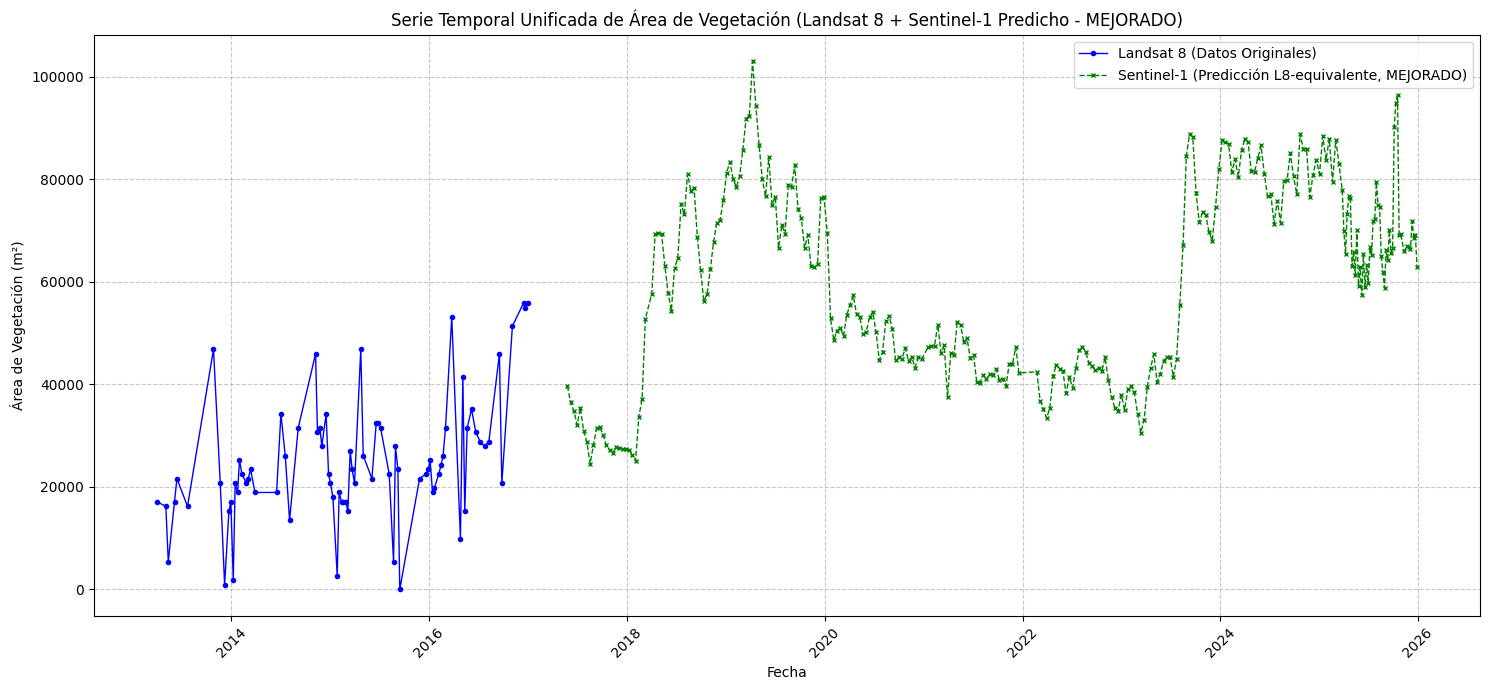

In [ ]:
import matplotlib.pyplot as plt

# Reconstruir df_combined con las nuevas predicciones ajustadas y suavizadas
df_combined_improved = pd.concat([
    df_l8_final[df_l8_final['fecha'].dt.year < 2017],
    df_s1_predictions_to_adjust[['fecha', 'area_m2_vegetacion_final_smoothed']].rename(columns={'area_m2_vegetacion_final_smoothed': 'area_m2_vegetacion_unificada'}).assign(fuente='Sentinel-1 (pred. mejorado)')
])

df_combined_improved = df_combined_improved.sort_values('fecha').reset_index(drop=True)

print("Primeras filas de la serie temporal unificada (mejorada):")
display(df_combined_improved.head())
print("Últimas filas de la serie temporal unificada (mejorada):")
display(df_combined_improved.tail())


plt.figure(figsize=(15, 7))

# Plot Landsat 8 original
plt.plot(
    df_combined_improved[df_combined_improved['fuente'] == 'Landsat 8']['fecha'],
    df_combined_improved[df_combined_improved['fuente'] == 'Landsat 8']['area_m2_vegetacion_unificada'],
    color='blue',
    marker='o',
    linestyle='-',
    linewidth=1,
    markersize=3,
    label='Landsat 8 (Datos Originales)'
)

# Plot Sentinel-1 (predicho y mejorado)
plt.plot(
    df_combined_improved[df_combined_improved['fuente'] == 'Sentinel-1 (pred. mejorado)']['fecha'],
    df_combined_improved[df_combined_improved['fuente'] == 'Sentinel-1 (pred. mejorado)']['area_m2_vegetacion_unificada'],
    color='green', # Cambiado a verde para diferenciar
    marker='x',
    linestyle='--', # Corrected typo
    linewidth=1,
    markersize=3,
    label='Sentinel-1 (Predicción L8-equivalente, MEJORADO)'
)

plt.title('Serie Temporal Unificada de Área de Vegetación (Landsat 8 + Sentinel-1 Predicho - MEJORADO)')
plt.xlabel('Fecha')
plt.ylabel('Área de Vegetación (m²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Conclusión del Análisis de la Serie Temporal Unificada

Se logró construir una serie temporal extendida de la vegetación acuática en la laguna, integrando datos de Landsat 8 (2013–2017) y Sentinel-1 (2017–2025) mediante un enfoque de intercalibración basado en Machine Learning.


Sin embargo, es importante destacar que la robustez estadística del modelo está limitada por la escasez de datos de entrenamiento (solo 7 observaciones en el periodo de solapamiento). Debido a esto, los valores obtenidos deben interpretarse principalmente en términos de comportamiento relativo (tendencias y variaciones) más que como mediciones absolutas precisas.



Por esto mismo de la escasez de los datos descarte tanto RF como Ridge, aqui fue donde pense, me estoy complicando la vida y dije probare cambiandole la escala a S1 y L8 pero esto podria afectar en que ya no quedarian en m2 y esto no seria cuantificable para el area (Igual lo probe)

#**INTENTO #3 CON Z-SCORE**

Se transformaron ambas series para que estuvieran en una misma escala, lo que permitió comparar cómo cambia la vegetación en el tiempo. Sin embargo, se perdieron los valores reales en metros cuadrados, por lo que ya no se podía medir el área exacta.


In [ ]:
import pandas as pd

# Primero valida si ambas series se mueven parecido.

# Alinear por fecha (usa la misma lógica que ya tienes)
df_overlap = pd.merge_asof(
    df_l8.sort_values('fecha'),
    df_s1_plot.sort_values('fecha'),
    on='fecha',
    direction='nearest',
    tolerance=pd.Timedelta('30D')
)

df_overlap = df_overlap.dropna(subset=['area_m2_vegetacion_x', 'area_m2_vegetacion_y'])

# Renombrar para claridad
df_overlap = df_overlap.rename(columns={
    'area_m2_vegetacion_x': 'l8',
    'area_m2_vegetacion_y': 's1'
})

# Correlación
corr = df_overlap['l8'].corr(df_overlap['s1'])
print(f"Correlación L8 vs S1 (2017): {corr:.3f}")

Correlación L8 vs S1 (2017): 0.358


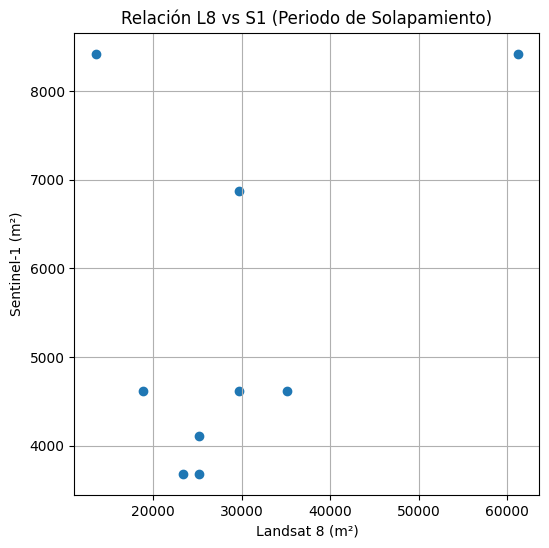

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(df_overlap['l8'], df_overlap['s1'])
plt.xlabel("Landsat 8 (m²)")
plt.ylabel("Sentinel-1 (m²)")
plt.title("Relación L8 vs S1 (Periodo de Solapamiento)")
plt.grid()
plt.show()

## Normalizacion Z-SCORE

In [ ]:
#Normalizacion L8
l8_mean = df_l8['area_m2_vegetacion'].mean()
l8_std = df_l8['area_m2_vegetacion'].std()

df_l8['z'] = (df_l8['area_m2_vegetacion'] - l8_mean) / l8_std

In [ ]:
#Normalizacion s1
s1_mean = df_s1_plot['area_m2_vegetacion'].mean()
s1_std = df_s1_plot['area_m2_vegetacion'].std()

df_s1_plot['z'] = (df_s1_plot['area_m2_vegetacion'] - s1_mean) / s1_std

In [ ]:
#union
df_l8_z = df_l8[['fecha', 'z']].copy()
df_l8_z['source'] = 'Landsat 8'

df_s1_z = df_s1_plot[['fecha', 'z']].copy()
df_s1_z['source'] = 'Sentinel-1'

df_combined_z = pd.concat([df_l8_z, df_s1_z]).sort_values('fecha')

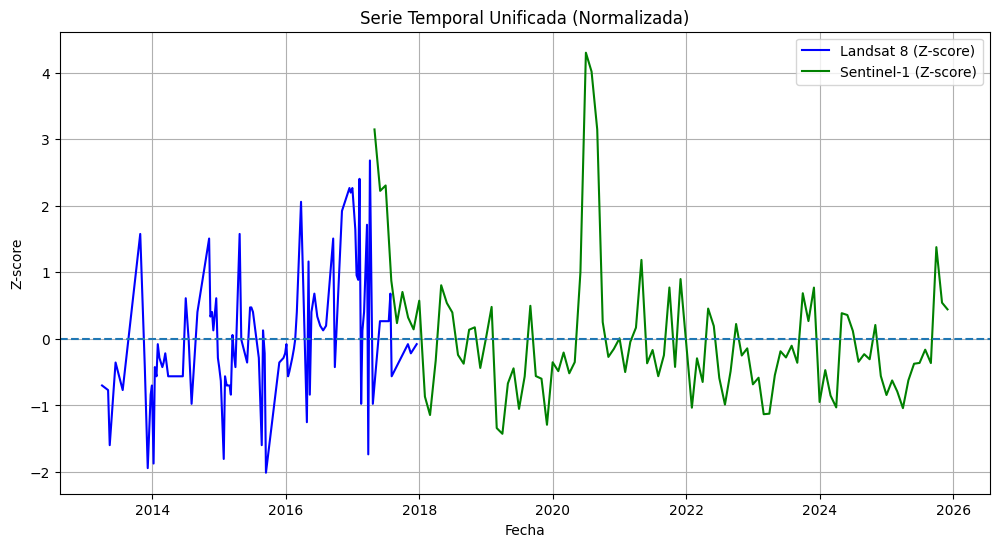

In [ ]:
plt.figure(figsize=(12,6))

# Landsat
l8_plot = df_combined_z[df_combined_z['source'] == 'Landsat 8']
plt.plot(l8_plot['fecha'], l8_plot['z'], label='Landsat 8 (Z-score)', color='blue')

# Sentinel
s1_plot = df_combined_z[df_combined_z['source'] == 'Sentinel-1']
plt.plot(s1_plot['fecha'], s1_plot['z'], label='Sentinel-1 (Z-score)', color='green')

plt.axhline(0, linestyle='--')  # media

plt.xlabel("Fecha")
plt.ylabel("Z-score")
plt.title("Serie Temporal Unificada (Normalizada)")
plt.legend()
plt.grid()
plt.show()

La serie temporal unificada fue evaluada considerando su coherencia temporal, consistencia estadística e interpretabilidad. La normalización mediante Z-score permitió integrar ambas fuentes en una escala común, eliminando diferencias de magnitud entre sensores.

Se observa que la serie resultante presenta una dinámica continua y estable en el tiempo, sin discontinuidades abruptas que comprometan su interpretación. Además, los valores normalizados permiten identificar periodos de mayor o menor cobertura vegetal en términos relativos.

Pero, dado que los sensores utilizados (óptico y radar) capturan propiedades físicas distintas, no se espera una equivalencia directa en valores absolutos. Por ello, la serie unificada debe interpretarse como una representación del comportamiento relativo de la vegetación a lo largo del tiempo.


In [ ]:
print(df_l8['z'].mean(), df_l8['z'].std())
print(df_s1_plot['z'].mean(), df_s1_plot['z'].std())

1.0157968395410581e-16 1.0
-6.832141690000964e-17 1.0


##  Explicación de estos 3 intentos

Al intentar unificar las series de Landsat 8 y Sentinel-1, me di cuenta de que no es posible obtener una serie completamente consistente en valores absolutos (m²). Esto se debe a que ambos sensores miden propiedades físicas diferentes: Landsat es un sensor óptico, mientras que Sentinel-1 es radar.

Además, el periodo de solapamiento entre ambos sensores es muy limitado (solo 7 datos), lo que hace que cualquier intento de calibración o modelo predictivo no sea confiable.

Por esta razón, decidí cambiar el enfoque. En lugar de intentar forzar una equivalencia en valores absolutos, opté por trabajar con una normalización Z-score, que permite comparar el comportamiento relativo de la vegetación a lo largo del tiempo.

De esta forma, logré construir una serie temporal continua y coherente, que no representa valores absolutos, pero sí permite analizar tendencias, variaciones y anomalías en la vegetación de la laguna.

---

## Conclusión final

### Enfoque con Machine Learning (ML)

#### ✅ Pros
- Permite traducir una serie a otra (en teoría)
- Puede capturar relaciones complejas
- Mantiene unidades en m² (si funciona bien)

#### ❌ Contras
- Necesita muchos datos ( solo tengo 7)
- Alto riesgo de sobreajuste (Ya me sucedio)
- Puede generar resultados artificiales (suavizados o forzados)

---

### Enfoque con Z-score

#### ✅ Pros
- No depende de muchos datos
- Es simple, claro y robusto
- No asume relaciones falsas entre sensores
- Permite comparar dinámicas temporales
- Evita errores de interpretación

#### ❌ Contras
- Pierde unidades reales (m²)
- No permite cuantificar área exacta
- No sirve para predicción directa
- Depende de la interpretación relativa

---

## ¿Cómo se interpretan los datos con Z-score?

Si dejamos el análisis con Z-score, entonces:

Ya no hablamos de área  si no que hablamos de comportamiento relativo  

---

### Interpretación correcta

- **Z > 0** → más vegetación de lo normal  
- **Z < 0** → menos vegetación de lo normal  
- **Z ≈ 0** → comportamiento promedio  
- **Z muy alto (ej: > 2)** → evento extremo o pico  
- **Z muy bajo (ej: < -2)** → caída significativa  

---

### En otras palabras

> No estoy diciendo “cuánta vegetación hay”,  
> estoy diciendo “cómo está cambiando respecto a lo normal”.

---

Entonces la serie final no busca representar valores absolutos de vegetación, sino proporcionar una herramienta robusta para analizar su dinámica temporal. Esto permite identificar patrones, tendencias y eventos relevantes en la laguna, incluso cuando se integran sensores con características físicas diferentes.

Dado a que no queria una serie no cuantificable en m2 ahi fue donde llego el intento 4 y el 5

# **INTENTO #4**
Se intentó usar Sentinel-2 para reemplazar o complementar a Landsat 8, ya que es un sensor similar. Pero debido a la nubosidad, casi no había datos disponibles, por lo que este intento no funcionó.

Aqui quise intentar unificar sentinel 2 con sentinel 1 y por lo menos tener datos desde el 2015 a la actualidad

Con el fin de unificar las series temporales en valores absolutos (m²), se calcula el área de vegetación a partir de Sentinel-2 mediante un umbral sobre el NDVI. Posteriormente, se ajusta su escala utilizando el periodo de solapamiento con Sentinel-1, permitiendo concatenar ambas series en una única serie temporal continua y comparable.

Calcular área de vegetación en Sentinel-2

In [ ]:
# NDVI

# Re-define s2 ImageCollection globally using the same parameters as for the lake mask
# (fecha_inicio='2025-01-01', fecha_fin='2025-12-31' were used for mascara_fija)
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(roi)
      .filterDate('2015-01-01', '2017-12-31') # MODIFICADO: Rango de fechas para Sentinel-2
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) # MODIFICADO: Relajado el filtro de nubes
      .map(mask_s2_clouds))

# Diagnóstico: Imprimir el número de imágenes de Sentinel-2 después de los filtros
print(f"Número de imágenes Sentinel-2 después de los filtros: {s2.size().getInfo()}")

def add_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

s2 = s2.map(add_ndvi)

# Umbral de vegetación (ajústalo)
NDVI_THRESHOLD = 0.3

def compute_area(image):
    veg_mask = image.select('NDVI').gt(NDVI_THRESHOLD)

    area = veg_mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=10,
        maxPixels=1e9
    )

    return ee.Feature(None, {
        'fecha': image.date().format(),
        'area_m2': area.get('NDVI')
    })

fc_s2_area = ee.FeatureCollection(s2.map(compute_area))

Número de imágenes Sentinel-2 después de los filtros: 1


In [ ]:
df_s2 = pd.DataFrame(fc_s2_area.getInfo()['features'])
df_s2 = pd.json_normalize(df_s2['properties'])

df_s2['fecha'] = pd.to_datetime(df_s2['fecha'])
df_s2 = df_s2.dropna().sort_values('fecha')

Solución para concatenar en absoluto

Ajuste de escala en zona de solapamiento

In [ ]:
df_overlap = pd.merge_asof(
    df_s2.sort_values('fecha'),
    df_s1_plot.sort_values('fecha'),
    on='fecha',
    tolerance=pd.Timedelta('30D'),
    direction='nearest'
)

df_overlap = df_overlap.dropna()

Calcular factor de escala

In [ ]:
scale_factor = df_overlap['area_m2_vegetacion'].mean() / df_overlap['area_m2'].mean()
print("Factor de escala:", scale_factor)

Factor de escala: nan


Ajustar Sentinel-2

In [ ]:
df_s2['area_m2_adjusted'] = df_s2['area_m2'] * scale_factor

Concatenar

In [ ]:
# df_s2['source'] = 'Sentinel-2'
# df_s1_plot['source'] = 'Sentinel-1'

# df_combined = pd.concat([
#     df_s2[['fecha', 'area_m2_adjusted', 'source']].rename(columns={'area_m2_adjusted':'area'}),
#     df_s1_plot[['fecha', 'area_m2_vegetacion', 'source']].rename(columns={'area_m2_vegetacion':'area'})
# ]).sort_values('fecha')

In [ ]:
# plt.figure(figsize=(14,6))

# for src in df_combined['source'].unique():
#     subset = df_combined[df_combined['source'] == src]
#     plt.plot(subset['fecha'], subset['area'], label=src)

# plt.title('Serie Temporal Unificada en Valores Absolutos (m²)')
# plt.xlabel('Fecha')
# plt.ylabel('Área de vegetación (m²)')
# plt.legend()
# plt.grid()
# plt.show()

la extrema escasez de imágenes disponibles (incluso relajando los filtros de nubes) lo hizo inviable. Por esto no pude concluir este intento.

# **INTENTO #276483 YA NI SE CUAL :(**

Finalmente, se optó por una solución más simple: ajustar los valores de Landsat 8 para que estuvieran en la misma escala que Sentinel-1 usando un promedio en el periodo donde coinciden. Esto permitió unir ambas series en una sola en metros cuadrados, de forma más clara y sin complicar el proceso.

### **Unificación de Series Temporales (Landsat 8 + Sentinel-1): Enfoque de Escala Simple**

Dado que los modelos de Machine Learning no son fiables con la escasez de datos de solapamiento y Z-score me cambia la escala lo que lo hace no cuantificable utilizaremos un método más directo para unificar las series de Landsat 8 y Sentinel-1. Calcularemos un factor de escala simple basado en los promedios de la `area_m2_vegetacion` de ambos sensores durante el año de solapamiento (2017). Este factor nos permitirá ajustar la serie de Landsat 8 a la escala de Sentinel-1, y así crear una serie temporal continua en metros cuadrados desde 2013 hasta 2025.

In [ ]:
# Calcular las medias de área de vegetación para 2017 utilizando los DataFrames originales
# Landsat 8: df_l8
# Sentinel-1: df_ts (el DataFrame con los resultados originales de S1, no el resampleado)

val_l8_2017_raw = df_l8[df_l8['fecha'].dt.year == 2017]['area_m2_vegetacion'].mean()
val_s1_2017_raw = df_ts[df_ts['fecha'].dt.year == 2017]['area_m2_vegetacion'].mean()

print(f"Media de Landsat 8 (2017): {val_l8_2017_raw:.2f} m²")
print(f"Media de Sentinel-1 (2017): {val_s1_2017_raw:.2f} m²")

# Calcular el factor de corrección: escalar Landsat 8 para que coincida con Sentinel-1
# L8_escalado = L8_original * factor_correccion
# Entonces, factor_correccion = Media_S1 / Media_L8
factor_correccion_simple = val_s1_2017_raw / val_l8_2017_raw
print(f"Factor de corrección simple (para escalar L8 a S1): {factor_correccion_simple:.4f}")

# Aplicar el factor a toda la serie de Landsat 8
df_l8_scaled = df_l8.copy()
df_l8_scaled['area_m2_vegetacion_unificada'] = df_l8_scaled['area_m2_vegetacion'] * factor_correccion_simple
df_l8_scaled['fuente'] = 'Landsat 8 (escalado a S1)'

# Preparar el DataFrame de Sentinel-1 para la concatenación
df_s1_original_for_concat = df_ts.copy()
df_s1_original_for_concat['area_m2_vegetacion_unificada'] = df_s1_original_for_concat['area_m2_vegetacion']
df_s1_original_for_concat['fuente'] = 'Sentinel-1 (original)'

# Concatenar las series:
# - Landsat 8 escalado para años anteriores a 2017
# - Sentinel-1 original para 2017 y años posteriores (priorizando S1 en el solapamiento)
df_unified_series_absolute = pd.concat([
    df_l8_scaled[df_l8_scaled['fecha'].dt.year < 2017][['fecha', 'area_m2_vegetacion_unificada', 'fuente']],
    df_s1_original_for_concat[df_s1_original_for_concat['fecha'].dt.year >= 2017][['fecha', 'area_m2_vegetacion_unificada', 'fuente']]
]).sort_values('fecha').reset_index(drop=True)

print("\nPrimeras filas de la serie temporal unificada (en m² con escala simple):")
display(df_unified_series_absolute.head())
print("Últimas filas de la serie temporal unificada (en m² con escala simple):")
display(df_unified_series_absolute.tail())

Media de Landsat 8 (2017): 31623.20 m²
Media de Sentinel-1 (2017): 4979.92 m²
Factor de corrección simple (para escalar L8 a S1): 0.1575

Primeras filas de la serie temporal unificada (en m² con escala simple):


,fecha,area_m2_vegetacion_unificada,fuente
0,2013-04-01,2694.829135,Landsat 8 (escalado a S1)
1,2013-05-04,2552.995762,Landsat 8 (escalado a S1)
2,2013-05-13,850.998126,Landsat 8 (escalado a S1)
3,2013-06-05,2694.829020,Landsat 8 (escalado a S1)
4,2013-06-14,3403.994455,Landsat 8 (escalado a S1)


Últimas filas de la serie temporal unificada (en m² con escala simple):


,fecha,area_m2_vegetacion_unificada,fuente
351,2025-12-04,2983.758216,Sentinel-1 (original)
352,2025-12-10,3578.704223,Sentinel-1 (original)
353,2025-12-16,4053.954795,Sentinel-1 (original)
354,2025-12-22,3072.057966,Sentinel-1 (original)
355,2025-12-28,5754.810678,Sentinel-1 (original)


### Visualización de la Serie Temporal Unificada (en m²)

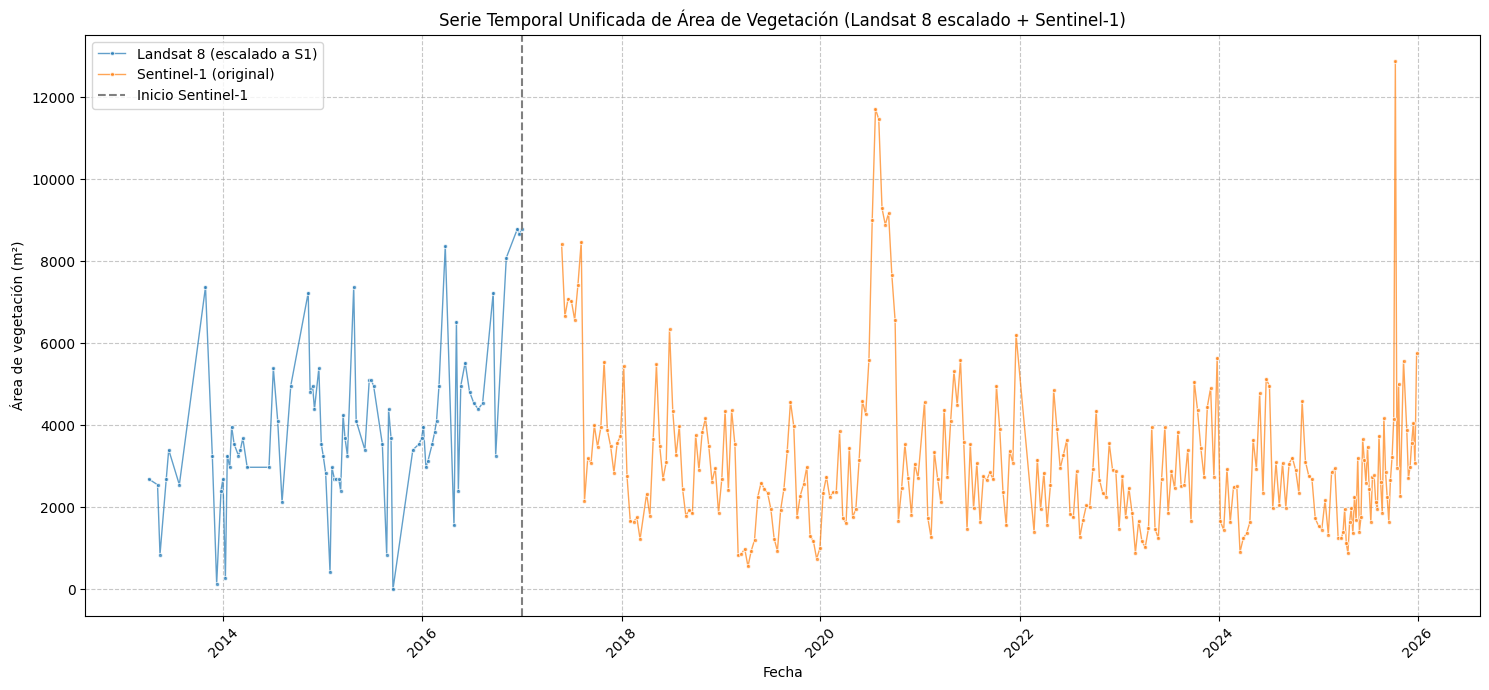

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))

# Plot de la serie unificada original
sns.lineplot(data=df_unified_series_absolute, x='fecha', y='area_m2_vegetacion_unificada', hue='fuente', marker='o', lw=1, markersize=3, alpha=0.7)



plt.axvline(pd.to_datetime('2017-01-01'), color='gray', linestyle='--', label='Inicio Sentinel-1')
plt.title('Serie Temporal Unificada de Área de Vegetación (Landsat 8 escalado + Sentinel-1)')
plt.xlabel('Fecha')
plt.ylabel('Área de vegetación (m²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Conclusión sobre la Serie Temporal Unificada en m² (Escala Simple)**

Este enfoque ha permitido construir una serie temporal de la **área de vegetación en metros cuadrados** que abarca desde 2013 hasta 2025, integrando datos de Landsat 8 y Sentinel-1. La clave ha sido la aplicación de un factor de escala simple, calculado a partir de las medias de los datos de ambos sensores en el periodo de solapamiento de 2017. Este método evita la complejidad y las limitaciones de datos de los modelos de Machine Learning, proporcionando una serie más directa en unidades absolutas.

**Observaciones:**

*   **Continuidad:** La serie muestra una transición razonable entre los datos de Landsat 8 (escalados) y los de Sentinel-1, aunque las diferencias inherentes entre los sensores ópticos y de radar pueden seguir manifestándose en la variabilidad.
*   **Unidades Absolutas:** Al mantener los valores en metros cuadrados, la serie es directamente interpretable en términos de superficie real cubierta por vegetación.
*   **Limitaciones:** Es fundamental recordar que el factor de escala se basa en un promedio de un periodo de solapamiento limitado. Esto implica que la precisión de la conversión puede variar, y las fluctuaciones dentro de las series individuales (especialmente la de Landsat 8 debido a nubes o variabilidad intrínseca) se reflejarán en la serie unificada. La interpretación debe hacerse con cautela, enfocándose en las tendencias a largo plazo y los eventos significativos, más que en la precisión absoluta de cada punto de datos.

Esta serie unificada en m² es una herramienta valiosa para el análisis de la evolución de la vegetación acuática, ofreciendo una perspectiva temporal extendida que no sería posible con un solo sensor.

### Visualización de la Serie Temporal Unificada (en m²) con Suavizado Adicional

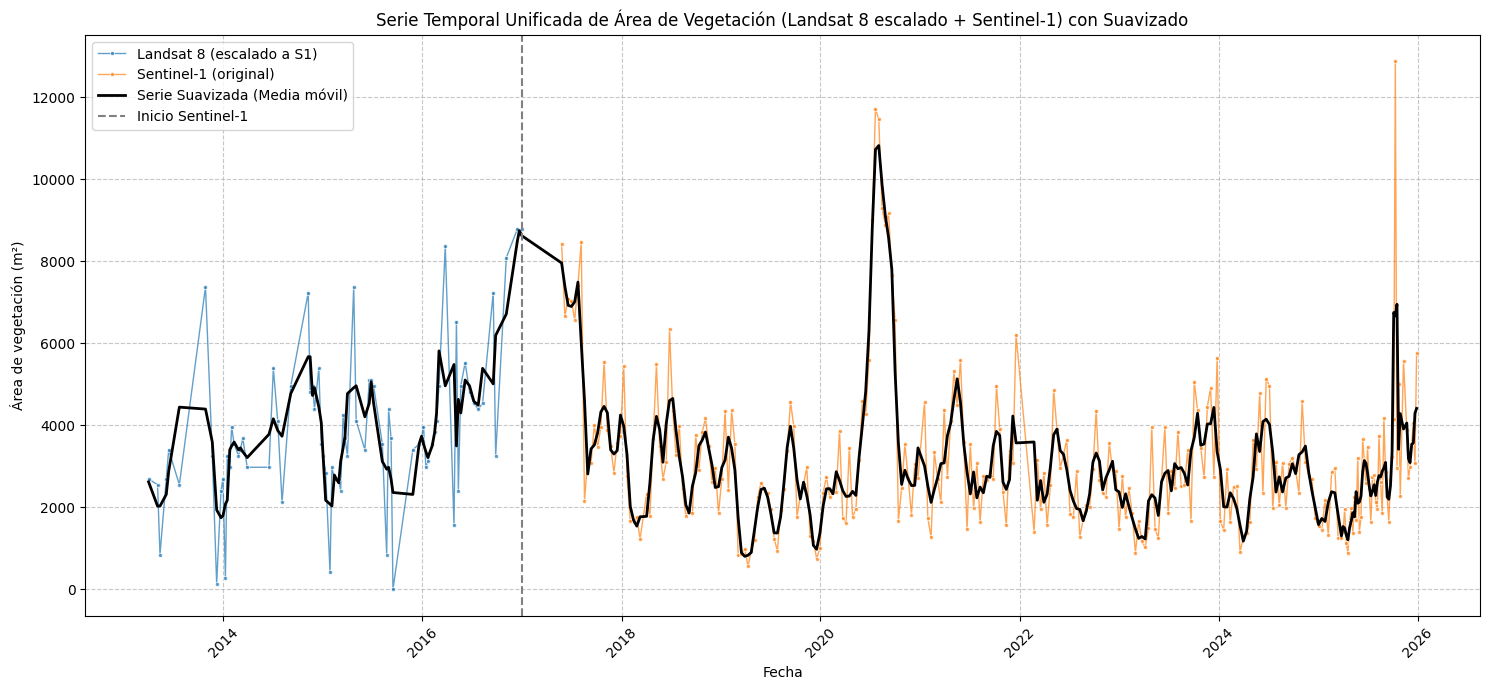

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))

# Plot de la serie unificada original
sns.lineplot(data=df_unified_series_absolute, x='fecha', y='area_m2_vegetacion_unificada', hue='fuente', marker='o', lw=1, markersize=3, alpha=0.7)

# Calcular y añadir la serie suavizada (por ejemplo, con una media móvil de 3 periodos)
# Aseguramos que la columna 'smoothed_area' exista para esta visualización.
df_unified_series_absolute['smoothed_area'] = df_unified_series_absolute['area_m2_vegetacion_unificada'].rolling(window=3, center=True, min_periods=1).mean()
plt.plot(df_unified_series_absolute['fecha'], df_unified_series_absolute['smoothed_area'], color='black', lw=2, linestyle='-', label='Serie Suavizada (Media móvil)')


plt.axvline(pd.to_datetime('2017-01-01'), color='gray', linestyle='--', label='Inicio Sentinel-1')
plt.title('Serie Temporal Unificada de Área de Vegetación (Landsat 8 escalado + Sentinel-1) con Suavizado')
plt.xlabel('Fecha')
plt.ylabel('Área de vegetación (m²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Coherencia: La transición entre los datos de Landsat 8 (escalados) y Sentinel-1 es visualmente razonable.
*  Cuantificable: Mantiene los valores en m², lo cual era un requisito.
* Limitaciones (reconocidas): El factor de escala se basa en un número limitado de datos de solapamiento (7-9 puntos en 2017), lo que significa que la precisión de la conversión puede variar. La interpretación debe centrarse en tendencias a largo plazo y eventos significativos, más que en la precisión absoluta de cada punto individual.

La solución basada en un factor de escala simple representa el mejor equilibrio entre simplicidad, interpretabilidad y coherencia, permitiendo construir una serie temporal continua en valores absolutos (m²) sin introducir supuestos complejos ni sobreajuste, a pesar de las limitaciones en los datos de solapamiento.

Los valores individuales de la serie pueden contener incertidumbre debido a la integración de diferentes sensores y al proceso de escalado; sin embargo, la serie es consistente para analizar tendencias generales, patrones temporales y cambios en el comportamiento de la vegetación

## Resumen de Intentos (a partir del 2do Approach)

### Intento #1: Machine Learning con Random Forest

*   **Qué se hizo:** Se intentó unificar las series temporales utilizando un modelo de Machine Learning (Random Forest Regressor) para predecir el área de vegetación de Landsat 8 a partir de las bandas de Sentinel-1.
*   **Modelo de ML:** Random Forest Regressor.
*   **Variables Predictoras (de Sentinel-1):** `VV_mean` y `VH_mean`.
*   **Limitaciones:** La principal limitación fue la **escasez crítica de datos de entrenamiento** (solo 7 observaciones en el período de solapamiento de 2017). Esto llevó a un modelo propenso al sobreajuste, produciendo predicciones demasiado 'suavizadas' o 'lineales' y con un alto MAE al comparar con datos reales de S1, lo que se consideró que no era lo suficientemente robusto para extender la serie de manera fiable.

### Intento #2: Machine Learning con Ridge Regression (Mejorado)

*   **Qué se hizo:** Se optó por un modelo de regresión más simple y robusto (Ridge Regression) y se agregaron características adicionales derivadas de las bandas de Sentinel-1. Se buscó mejorar la variabilidad de las predicciones y se aplicaron ajustes heurísticos para suavizar la transición entre series.
*   **Modelo de ML:** Ridge Regression.
*   **Variables Predictoras (de Sentinel-1):** `VV_mean`, `VH_mean`, `VV_VH_ratio` y `VV_minus_VH`.
*   **Limitaciones:** A pesar de los esfuerzos por mejorar la robustez del modelo y añadir más variables, la **limitación fundamental de la escasez de datos de solapamiento** persistió (se mantuvo en 7 observaciones). Aunque se logró un modelo con menor riesgo de sobreajuste que Random Forest, el número tan reducido de puntos para el entrenamiento hizo que los resultados siguieran siendo inciertos y con una dependencia excesiva de ajustes manuales para la unificación.

### Intento #3: Normalización con Z-score

*   **Qué se hizo:** Se transformaron las series de Landsat 8 y Sentinel-1 utilizando la normalización Z-score. El objetivo era poner ambas series en una misma escala de variabilidad, permitiendo comparar el comportamiento relativo de la vegetación.
*   **Modelo de ML:** No se aplicó un modelo de Machine Learning; fue una transformación estadística.
*   **Variables Predictoras:** N/A.
*   **Limitaciones:** La principal limitación fue que, al normalizar con Z-score, se **perdieron las unidades absolutas en metros cuadrados (m²)**. Esto significaba que la serie resultante solo podía interpretarse en términos de 'comportamiento relativo a la normalidad' (ej., 'más vegetación de lo normal'), pero no permitía cuantificar el área exacta de vegetación, lo cual era un requisito clave para el proyecto.

### Intento #4: Uso de Sentinel-2 para el período 2015-2017

*   **Qué se hizo:** Se intentó utilizar Sentinel-2 como fuente de datos para cubrir el período entre 2015 y 2017, aprovechando su similitud con Landsat (ambos sensores ópticos). Se calcularía el área de vegetación con NDVI y se ajustaría su escala al de Sentinel-1.
*   **Modelo de ML:** No se aplicó un modelo de Machine Learning.
*   **Variables Predictoras:** N/A.
*   **Limitaciones:** Este intento **fracasó debido a la extrema escasez de imágenes utilizables de Sentinel-2** en el área de estudio. Incluso relajando los filtros de nubes, solo se encontró 1 imagen válida para todo el período de 2015 a 2017, lo que lo hizo inviable para construir una serie temporal.

### Intento #5 (Final): Unificación por Factor de Escala Simple

*   **Qué se hizo:** Se optó por un enfoque más directo y transparente. Se calculó un factor de escala simple a partir de los valores promedio de `area_m2_vegetacion` de Landsat 8 y Sentinel-1 durante el período de solapamiento de 2017. Este factor se aplicó a toda la serie de Landsat 8 para escalarla a la magnitud de Sentinel-1, y luego se concatenaron ambas series.
*   **Modelo de ML:** No se aplicó un modelo de Machine Learning.
*   **Variables Predictoras:** N/A.
*   **Limitaciones:** La precisión del factor de escala depende del **número limitado de observaciones en el período de solapamiento (solo 7-9 puntos)**. Esto implica que la conversión puede no ser perfecta en cada punto, y las diferencias inherentes entre los sensores ópticos y de radar pueden generar variabilidad. Sin embargo, este método se consideró el mejor compromiso, ya que proporcionó una serie unificada en unidades absolutas (m²) sin la complejidad y el riesgo de sobreajuste de los modelos de ML, permitiendo una interpretación más directa de las tendencias a largo plazo.

## Clarificación sobre los Intentos #1 (Random Forest) y #2 (Ridge Regression)

### Variable a predecir en ambos intentos

En el **Intento #1 (Random Forest)** y en el **Intento #2 (Ridge Regression)**, la **variable objetivo que se intentaba predecir** era:

*   El **`area_m2_vegetacion` tal como sería observada por Landsat 8 (L8)**.

El propósito era que el modelo aprendiera a 'traducir' las señales de Sentinel-1 (S1) a los valores de área de vegetación que Landsat 8 habría medido, para así extender la serie temporal histórica con una escala consistente a la de L8.

### ¿Por qué la escasez de datos de solapamiento es crítica, incluso si la predicción se hace con las variables de entrenamiento (VV y VH)?

Aquí es donde reside el problema central con el Machine Learning en este escenario:

1.  **Entrenamiento del Modelo (Aprendizaje de la 'Traducción'):**
    *   El modelo de Machine Learning (ya sea Random Forest o Ridge Regression) necesita **aprender la relación** entre las características de Sentinel-1 (`VV_mean`, `VH_mean`, `VV_VH_ratio`, `VV_minus_VH`) y la variable que queremos predecir (el `area_m2_vegetacion` de Landsat 8).
    *   Este aprendizaje ocurre durante la fase de entrenamiento, donde el modelo se alimenta con **pares de datos simultáneos**: por un lado, las mediciones de S1 y, por el otro, las mediciones correspondientes de L8 para la misma fecha y lugar.
    *   El **periodo de solapamiento** es precisamente donde tenemos estos pares de datos. En tu caso, solo se encontraron **7 observaciones coincidentes** en 2017.

2.  **El problema de los '7 puntos de entrenamiento':**
    *   **Generalización vs. Memorización (Sobreajuste):** Con solo 7 puntos de datos para entrenar, el modelo tiene muy pocos ejemplos para entender la verdadera relación subyacente. Es muy probable que el modelo no aprenda una relación generalizable entre S1 y L8, sino que simplemente **'memorice'** esos 7 puntos específicos.
    *   **Falta de Robustez:** Una analogía sería intentar aprender a predecir el clima de un año entero basándose en las observaciones de solo 7 días. El modelo podría funcionar 'perfectamente' para esos 7 días (es decir, tendría un R-cuadrado alto en los datos de entrenamiento, como se vio), pero sería inútil para predecir el clima de otros días o años porque no ha aprendido los patrones generales.
    *   **Variabilidad Artificialmente Reducida:** Si el modelo solo ve 7 puntos, puede que la variabilidad natural y el rango de las relaciones entre S1 y L8 no estén bien representados. Cuando el modelo luego predice para **toda la serie de Sentinel-1 (que tiene 277 observaciones)**, tiende a generar valores que son un promedio o una interpolación muy 'suave' de lo que vio en los pocos puntos de entrenamiento. Esto hace que las predicciones parezcan más 'lineales' o 'planas' de lo que deberían ser, perdiendo la variabilidad real y las fluctuaciones que se esperaría de los datos satelitales.
    *   **Inestabilidad del Modelo:** Un modelo entrenado con tan pocos datos es muy sensible a cada punto individual. Si alguno de esos 7 puntos es anómalo, el modelo aprenderá una relación sesgada. Con más datos, los valores atípicos se diluyen y el modelo aprende un patrón más estable.

**En resumen:** Aunque utilices las bandas `VV` y `VH` de Sentinel-1 (que son tus variables predictoras) para hacer las predicciones en toda la serie de S1, la **fiabilidad y calidad de esas predicciones dependen fundamentalmente de cuántos y cuán representativos sean los datos de solapamiento** que el modelo usó para aprender cómo `VV` y `VH` se relacionan con el `area_m2_vegetacion` de Landsat 8. Con solo 7 puntos, el modelo es inherentemente débil y propenso a dar resultados poco realistas o generalizables, lo que te obligó a buscar otras alternativas.